# Regresión lineal 


Si asesora a una empresa automotriz, intenta comprender los factores que influyen en el precio de venta de los autos. En concreto, ¿qué factores impulsan el aumento de precio? ¿Y con qué precisión puede predecir el precio de venta basándose en las características del auto?

En este cuaderno, realizaremos un análisis de regresión lineal simple en un conjunto de datos de precios de automóviles, mostraremos cómo se realiza este análisis de predicción y cuáles son los supuestos importantes que deben cumplirse para la regresión lineal. También analizaremos diferentes maneras de transformar nuestros datos.

**Objetivos:** Después de completar este laboratorio, usted podrá:

* Seleccione las características significativas basándose en el análisis visual
* Verifique los supuestos del modelo de regresión lineal
* Aplicar el modelo de regresión lineal y realizar las predicciones
* Aplicar las canalizaciones para transformar los datos.

**Configuración**

Para este laboratorio, utilizaremos las siguientes bibliotecas:

- [`pandas`](https://pandas.pydata.org/)  para gestionar los datos.
- [`numpy`](https://numpy.org/) para operaciones matemáticas.
- [`seaborn`](https://seaborn.pydata.org/) para visualizar los datos.
- [`matplotlib`](https://matplotlib.org/) para visualizar los datos.
- [`sklearn`](https://scikit-learn.org/stable/) para funciones relacionadas con el aprendizaje automático y la canalización del aprendizaje automático.
- [`scipy`](https://docs.scipy.org/doc/scipy/tutorial/stats.html/) para cálculos estadísticos.

## Importar las bibliotecas necesarias

In [2]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
#!pip install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

In [3]:
#!pip install pandas
#!pip install numpy
#!pip install matplotlib
#!pip install seaborn

In [4]:
#!pip install -U scikit-learn

In [5]:
import sklearn; 
print("Scikit-Learn", sklearn.__version__)

Scikit-Learn 1.5.1


In [6]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [7]:
import pandas as pd
import numpy as np 

import seaborn as sns 
import matplotlib.pylab as plt
%matplotlib inline


from scipy.stats import boxcox
from scipy.stats.mstats import normaltest

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 
from sklearn.metrics import mean_squared_error

from sklearn.pipeline import Pipeline

import sys
# Agregar la ruta donde se encuentra tu archivo .py
sys.path.append(r"C:\Users\LENOVO\Downloads\Latex\CursosML\IBM")

# Ahora puedes importar tu módulo
import Funciones_ML as ML


<h2> Funciones </h2>

## Leyendo y entendiendo nuestros datos

For this lab, we will be using the car sales dataset, hosted on IBM Cloud object storage. This dataset can also be found and downloaded from [kaggle.com](https://www.kaggle.com/datasets/goyalshalini93/car-data), an open public data source.
The dataset contains all the information about cars, a name of a manufacturer, all car's technical parameters and a sale price of a car.


Let's read the data into *pandas* data frame and look at the first 5 rows using the `head()` method.


In [12]:
data = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/data/CarPrice_Assignment.csv')
data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


# Diccionario de Variables — CarPrice_Assignment.csv

| Columna | Significado |
|--------|-------------|
| **car_ID** | Identificador único de cada auto / registro (número entero). |
| **symboling** | Calificación de riesgo de seguro asignada al auto; indica cuán “arriesgado” se considera el vehículo. Un valor de +3 indica alto riesgo; un valor2de –3 indica que probablemente es “bastante seguro”. |
| **CarName** | Nombre de la marca y modelo del automóvil (ej: “audi 100 ls”, “bmw 320i”, etc.). |
| **fueltype** | Tipo de combustible del auto — por lo general “gas” o “diesel”. |
| **aspiration** | Tipo de “aspiración” del motor — típicamente “std” (normal) o “turbo”. |
| **doornumber** | Número de puertas del auto — por ejemplo “two” (dos) o “four” (cuatro). |
| **carbody** | Tipo de carrocería del auto — por ejemplo “sedan”, “hatchback”, “wagon”, “convertible”, etc. |
| **drivewheel** | Tipo de tracción / ruedas motrices — por ejemplo “fwd” (delantera), “rwd” (trasera), “4wd” (tracción en las 4 ruedas). |
| **enginelocation** | Ubicación del motor en el auto — típicamente “front” (delantero) o “rear” (trasero). |
| **wheelbase** | Distancia entre ejes (ruedas delanteras y traseras). Representa la “base de ruedas”. |
| **carlength** | Longitud total del auto. |
| **carwidth** | Ancho del auto. |
| **carheight** | Altura del auto. |
| **curbweight** | Peso del auto sin ocupantes ni carga (peso “en vacío”). |
| **enginetype** | Tipo de motor — categoría que describe su arquitectura (por ejemplo, “ohc”, “dohc”, etc.). |
| **cylindernumber** | Número de cilindros del motor — por ejemplo “four”, “six”, “eight”, etc. |
| **enginesize** | Tamaño del motor — una medida numérica que usualmente representa el desplazamiento del motor. |
| **fuelsystem** | Sistema de combustible que utiliza el auto — diferentes configuraciones técnicas (inyección, carburación, etc.). |
| **boreratio** | Ratio / diámetro del cilindro del motor (“bore ratio”). Parámetro técnico del motor. |
| **stroke** | “Stroke” del motor — distancia que recorre el pistón dentro del cilindro. |
| **compressionratio** | Relación de compresión del motor — indicador de cuánto se comprime la mezcla combustible-aire. |
| **horsepower** | Caballos de fuerza (potencia) del motor. |
| **peakrpm** | Revoluciones por minuto máximas (pico de RPM) — indica a qué revoluciones entrega su potencia máxima el motor. |
| **citympg** | Rendimiento de combustible en ciudad — millas por galón en condiciones urbanas. |
| **highwaympg** | Rendimiento de combustible en carretera. |
| **price** | Precio del auto — variable objetivo (dependiente). |


We can find more information about the features and types using the `info()`  method.


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

According to the output above, we have 205 entries or rows, as well as 26 features. The "Non-Null Count" column shows the number of non-null entries.  If the count is 205 then there is no missing values for that particular feature. The 'price' is our target, or response variable, and the rest of the features are our predictor variables.

We also have a mix of numerical (8 int64 and 8 float64) and object data types (10 object). 

The `describe()` function will provide the statistical information about all numeric values.


In [17]:
data.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


<h2> Limpieza y gestión de datos </h2>

Here, we will check if we have any missing values.


In [20]:
data.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

Also, check for any duplicates by running `duplicated()` function through 'car_ID' records, since each row has a unique car ID value.


In [22]:
# Verifica que no existan valores duplicados en la columna 'car_ID'.
# data.duplicated(subset='car_ID') genera una serie booleana donde True = duplicado.
# sum(...) cuenta cuántos duplicados hay.
# La expresión completa devuelve True si NO hay duplicados (suma == 0).
sum(data.duplicated(subset='car_ID')) == 0

True

Next, let's look into some of our object variables first. Using `unique()` function, we will describe all categories of the 'CarName' attribute.


In [24]:
data["CarName"].unique()

array(['alfa-romero giulia', 'alfa-romero stelvio',
       'alfa-romero Quadrifoglio', 'audi 100 ls', 'audi 100ls',
       'audi fox', 'audi 5000', 'audi 4000', 'audi 5000s (diesel)',
       'bmw 320i', 'bmw x1', 'bmw x3', 'bmw z4', 'bmw x4', 'bmw x5',
       'chevrolet impala', 'chevrolet monte carlo', 'chevrolet vega 2300',
       'dodge rampage', 'dodge challenger se', 'dodge d200',
       'dodge monaco (sw)', 'dodge colt hardtop', 'dodge colt (sw)',
       'dodge coronet custom', 'dodge dart custom',
       'dodge coronet custom (sw)', 'honda civic', 'honda civic cvcc',
       'honda accord cvcc', 'honda accord lx', 'honda civic 1500 gl',
       'honda accord', 'honda civic 1300', 'honda prelude',
       'honda civic (auto)', 'isuzu MU-X', 'isuzu D-Max ',
       'isuzu D-Max V-Cross', 'jaguar xj', 'jaguar xf', 'jaguar xk',
       'maxda rx3', 'maxda glc deluxe', 'mazda rx2 coupe', 'mazda rx-4',
       'mazda glc deluxe', 'mazda 626', 'mazda glc', 'mazda rx-7 gs',
       'mazda glc 

We can see that the 'CarName' includes both the company name (brand) and the car model. Next, we want to split a company name from the model of a car, as for our model building purpose, we will focus on a company name only. 


In [26]:
# Extrae la marca del automóvil a partir de la columna 'CarName':
# 1) .str.split(' '): divide el nombre por espacios.
# 2) .str.get(0): toma la primera palabra (la marca).
# 3) .str.lower(): convierte todo a minúsculas para estandarizar.
data['brand'] = data.CarName.str.split(' ').str.get(0).str.lower()


Let's view all the `unique()` brands now.


In [28]:
data.brand.unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

There are some typos in the names of the cars, so they should be corrected.


In [30]:
# Corrige errores ortográficos y estandariza nombres de marcas:
# Reemplaza 'vw' y 'vokswagen' por 'volkswagen'
data['brand'] = data['brand'].replace(['vw', 'vokswagen'], 'volkswagen')

# Reemplaza la variante mal escrita 'maxda' por 'mazda'
data['brand'] = data['brand'].replace(['maxda'], 'mazda')

# Reemplaza la variante mal escrita 'porcshce' por 'porsche'
data['brand'] = data['brand'].replace(['porcshce'], 'porsche')

# Reemplaza la variante mal escrita 'toyouta' por 'toyota'
data['brand'] = data['brand'].replace(['toyouta'], 'toyota')


In [31]:
data.brand.unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
       'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

Let's plot and sort the total number of Brands.


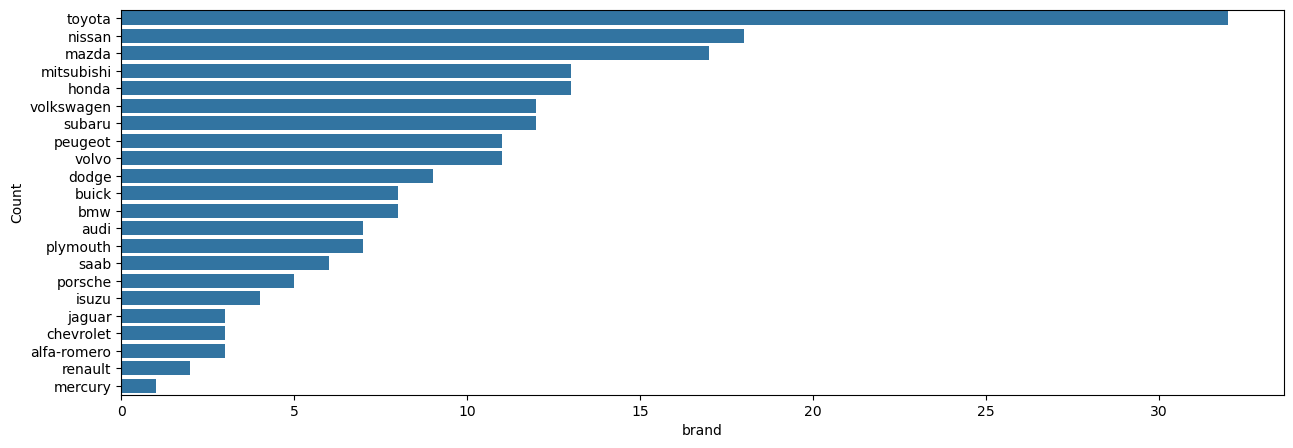

<Figure size 640x480 with 0 Axes>

In [33]:
ML.grafico_conteo_horizontal(data, 'brand')

We can drop 'car_ID', 'symboling', and 'CarName' from our data frame, since they will no longer be needed.


In [35]:
data.drop(['car_ID', 'symboling', 'CarName'],axis = 1, inplace = True)

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fueltype          205 non-null    object 
 1   aspiration        205 non-null    object 
 2   doornumber        205 non-null    object 
 3   carbody           205 non-null    object 
 4   drivewheel        205 non-null    object 
 5   enginelocation    205 non-null    object 
 6   wheelbase         205 non-null    float64
 7   carlength         205 non-null    float64
 8   carwidth          205 non-null    float64
 9   carheight         205 non-null    float64
 10  curbweight        205 non-null    int64  
 11  enginetype        205 non-null    object 
 12  cylindernumber    205 non-null    object 
 13  enginesize        205 non-null    int64  
 14  fuelsystem        205 non-null    object 
 15  boreratio         205 non-null    float64
 16  stroke            205 non-null    float64
 1

In [37]:
#If you need to save this partially processed data, uncomment the line below.
data.to_csv('cleaned_car_data.csv', index=False)

## Exercise 1
In this exercise, explore any (or all) object variables of your interest.


In [39]:
data.fueltype.unique()

array(['gas', 'diesel'], dtype=object)

In [40]:
data["enginelocation"].value_counts()

enginelocation
front    202
rear       3
Name: count, dtype: int64

A continuación, necesitamos diseñar algunas características para mejorar la visualización y el análisis. Agruparemos nuestros datos por 'brand', calcularemos el precio promedio de cada brand y los dividiremos en tres categorías: 'Budget', 'Mid-Range', and 'Luxury' . Asignaremos a la columna recién creada el nombre "brand_category".

In [42]:
# Seleccionamos las columnas 'brand' y 'price' del DataFrame 'data'
# Luego agrupamos los datos por la columna 'brand', sin usar 'brand' como índice
# Calculamos la media de los precios por cada marca
# Finalmente, renombramos la columna resultante de la media de 'price' a 'brand_avg_price'
data_comp_avg_price = data[['brand','price']] \
                        .groupby('brand', as_index=False) \
                        .mean() \
                        .rename(columns={'price':'brand_avg_price'})
# Mostramos el DataFrame resultante
data_comp_avg_price

,brand,brand_avg_price
0,alfa-romero,15498.333333
1,audi,17859.166714
2,bmw,26118.750000
3,buick,33647.000000
4,chevrolet,6007.000000
5,dodge,7875.444444
6,honda,8184.692308
7,isuzu,8916.500000
8,jaguar,34600.000000
9,mazda,10652.882353


In [43]:
data = data.merge(data_comp_avg_price, on = 'brand')
data

,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand,brand_avg_price
0,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,...,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,15498.333333
1,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,...,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,15498.333333
2,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,...,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,15498.333333
3,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,...,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,17859.166714
4,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,...,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,17859.166714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,...,3.78,3.15,9.5,114,5400,23,28,16845.0,volvo,18063.181818
201,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,...,3.78,3.15,8.7,160,5300,19,25,19045.0,volvo,18063.181818
202,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,...,3.58,2.87,8.8,134,5500,18,23,21485.0,volvo,18063.181818
203,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,...,3.01,3.40,23.0,106,4800,26,27,22470.0,volvo,18063.181818


Ahora comprobaremos las estadísticas de nuestro precio medio de coche por marca de coche.

In [45]:
data.brand_avg_price.describe()

count      205.000000
mean     13276.710571
std       7154.179185
min       6007.000000
25%       9239.769231
50%      10077.500000
75%      15489.090909
max      34600.000000
Name: brand_avg_price, dtype: float64

In [46]:
# Creamos una nueva columna llamada 'brand_category' en el DataFrame 'data'
# Esta columna se define en función de los valores de 'brand_avg_price' usando una función lambda
data['brand_category'] = data['brand_avg_price'].apply(
    lambda x: "Budget" if x < 10000            # Si el precio promedio de la marca es menor a 10,000 → categoría "Budget"
              else ("Mid_Range" if 10000 <= x < 20000  # Si está entre 10,000 y 20,000 → categoría "Mid_Range"
                    else "Luxury")            # Si es 20,000 o más → categoría "Luxury"
)

Análisis exploratorio de datos 
## Lista de variables categóricas:

- brand_category
- fueltype
- enginetype
- carbody
- doornumber
- enginelocation
- fuelsystem
- cylindernumber
- aspiration
- drivewheel

Utilizaremos la función `boxplot()` sobre las variables categóricas mencionadas anteriormente, para mostrar la media, la varianza y los posibles valores atípicos, con respecto al precio.

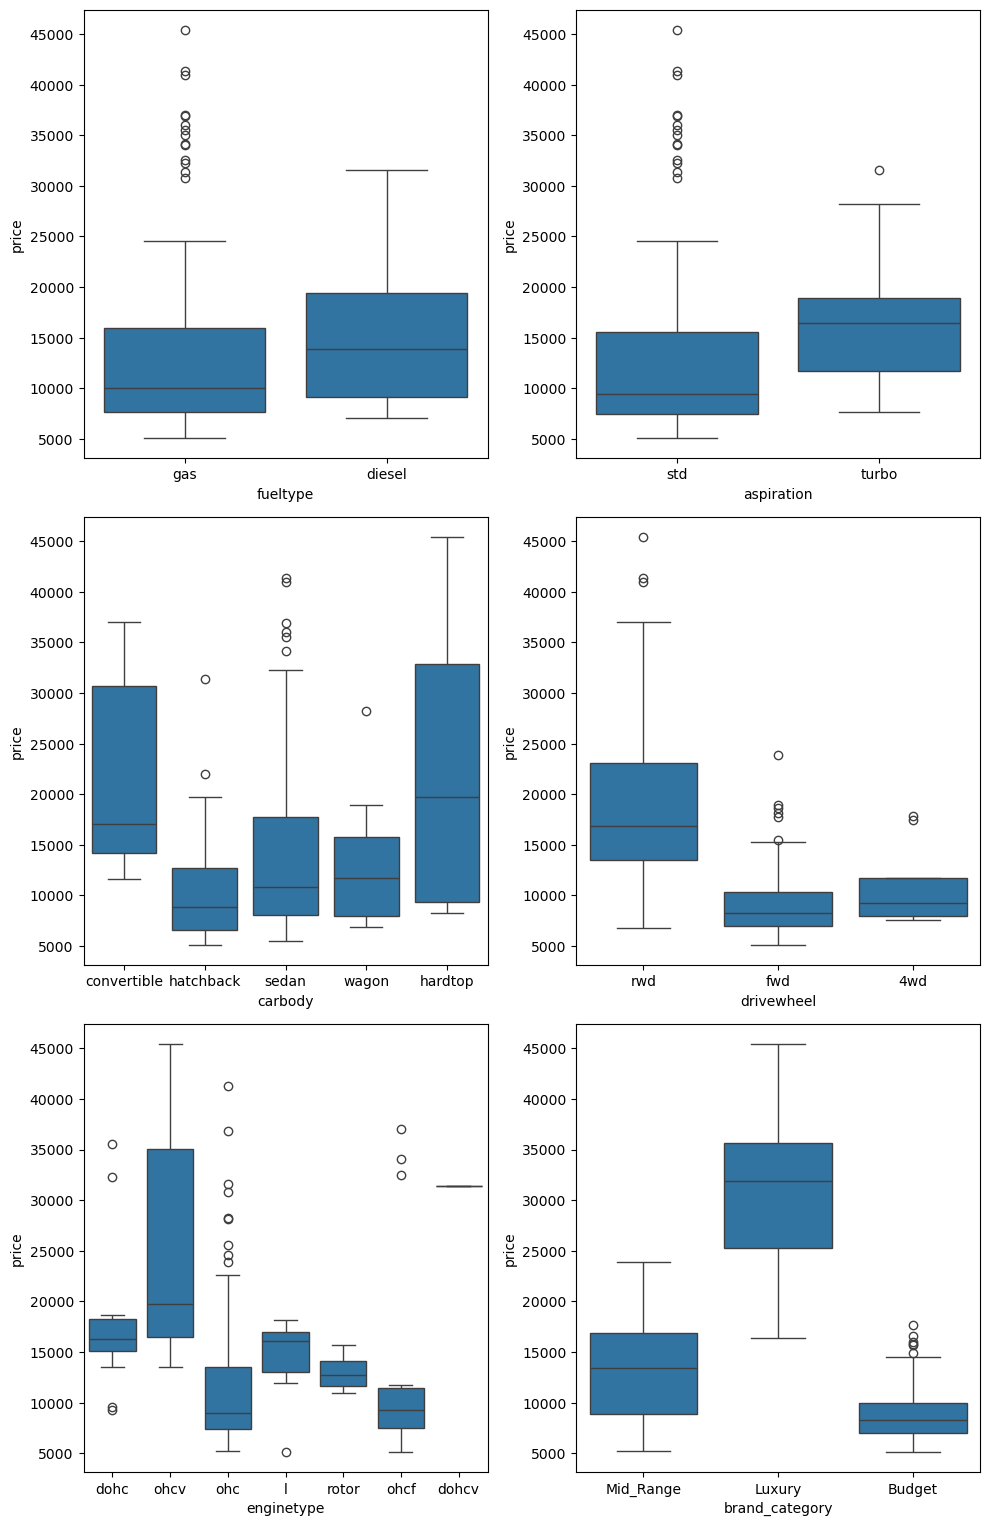

In [48]:
plt.figure(figsize=(10, 20))
plt.subplot(4,2,1)
sns.boxplot(x = 'fueltype', y = 'price', data = data)
plt.subplot(4,2,2)
sns.boxplot(x = 'aspiration', y = 'price', data = data)
plt.subplot(4,2,3)
sns.boxplot(x = 'carbody', y = 'price', data = data)
plt.subplot(4,2,4)
sns.boxplot(x = 'drivewheel', y = 'price', data = data)
plt.subplot(4,2,5)
sns.boxplot(x = 'enginetype', y = 'price', data = data)
plt.subplot(4,2,6)
sns.boxplot(x = 'brand_category', y = 'price', data = data)
plt.tight_layout()
plt.show()

A continuación, veamos la lista de las principales características con un alto coeficiente de correlación. La función `corr()` calcula los coeficientes de **correlación de Pearson** con respecto al precio.

In [50]:
# Ejemplos de uso:
# Correlación de todas las columnas con 'price'
correlacion_precio = ML.correlacion_con_objetivo(data, 'price')
# Correlación de las 5 columnas más correlacionadas con 'price'
#top5_correlacion_precio = correlacion_con_objetivo(data, 'price', top_n=5)
correlacion_precio

price               1.000000
brand_avg_price     0.895520
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
peakrpm            -0.085267
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64

Estas son características numéricas fuertemente correlacionadas con el precio del automóvil.

También podemos utilizar el `heatmap()` o `pairplot()` para explorar más a fondo la relación entre todas las características y las variables objetivo.

Variables con correlación ≥ 0.6 con 'price':
          Variable  Correlación
0  brand_avg_price     0.895520
1       enginesize     0.874145
2       curbweight     0.835305
3       horsepower     0.808139
4         carwidth     0.759325
5       highwaympg    -0.697599
6          citympg    -0.685751
7        carlength     0.682920


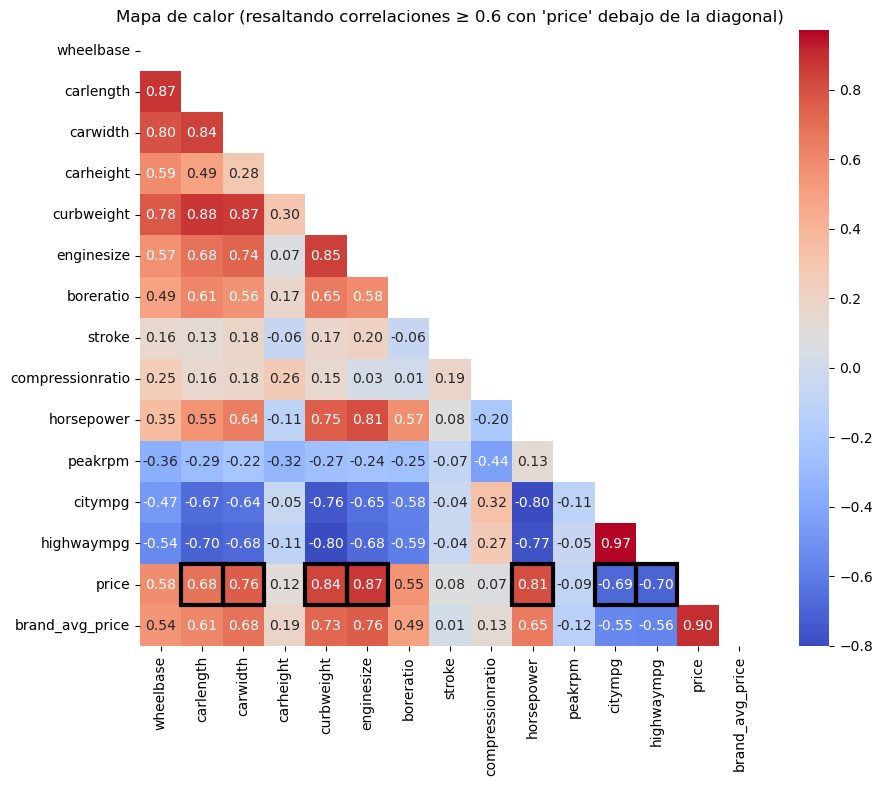

,Variable,Correlación
0,brand_avg_price,0.895520
1,enginesize,0.874145
2,curbweight,0.835305
3,horsepower,0.808139
4,carwidth,0.759325
5,highwaympg,-0.697599
6,citympg,-0.685751
7,carlength,0.682920


In [52]:
ML.variables_mas_correlacionadas_grafico(data, variable_objetivo='price', umbral=0.6)

## Ejercicio 2 
Utilice esta función `pairplot()`  para mostrar los gráficos de dispersión de las relaciones entre las características.

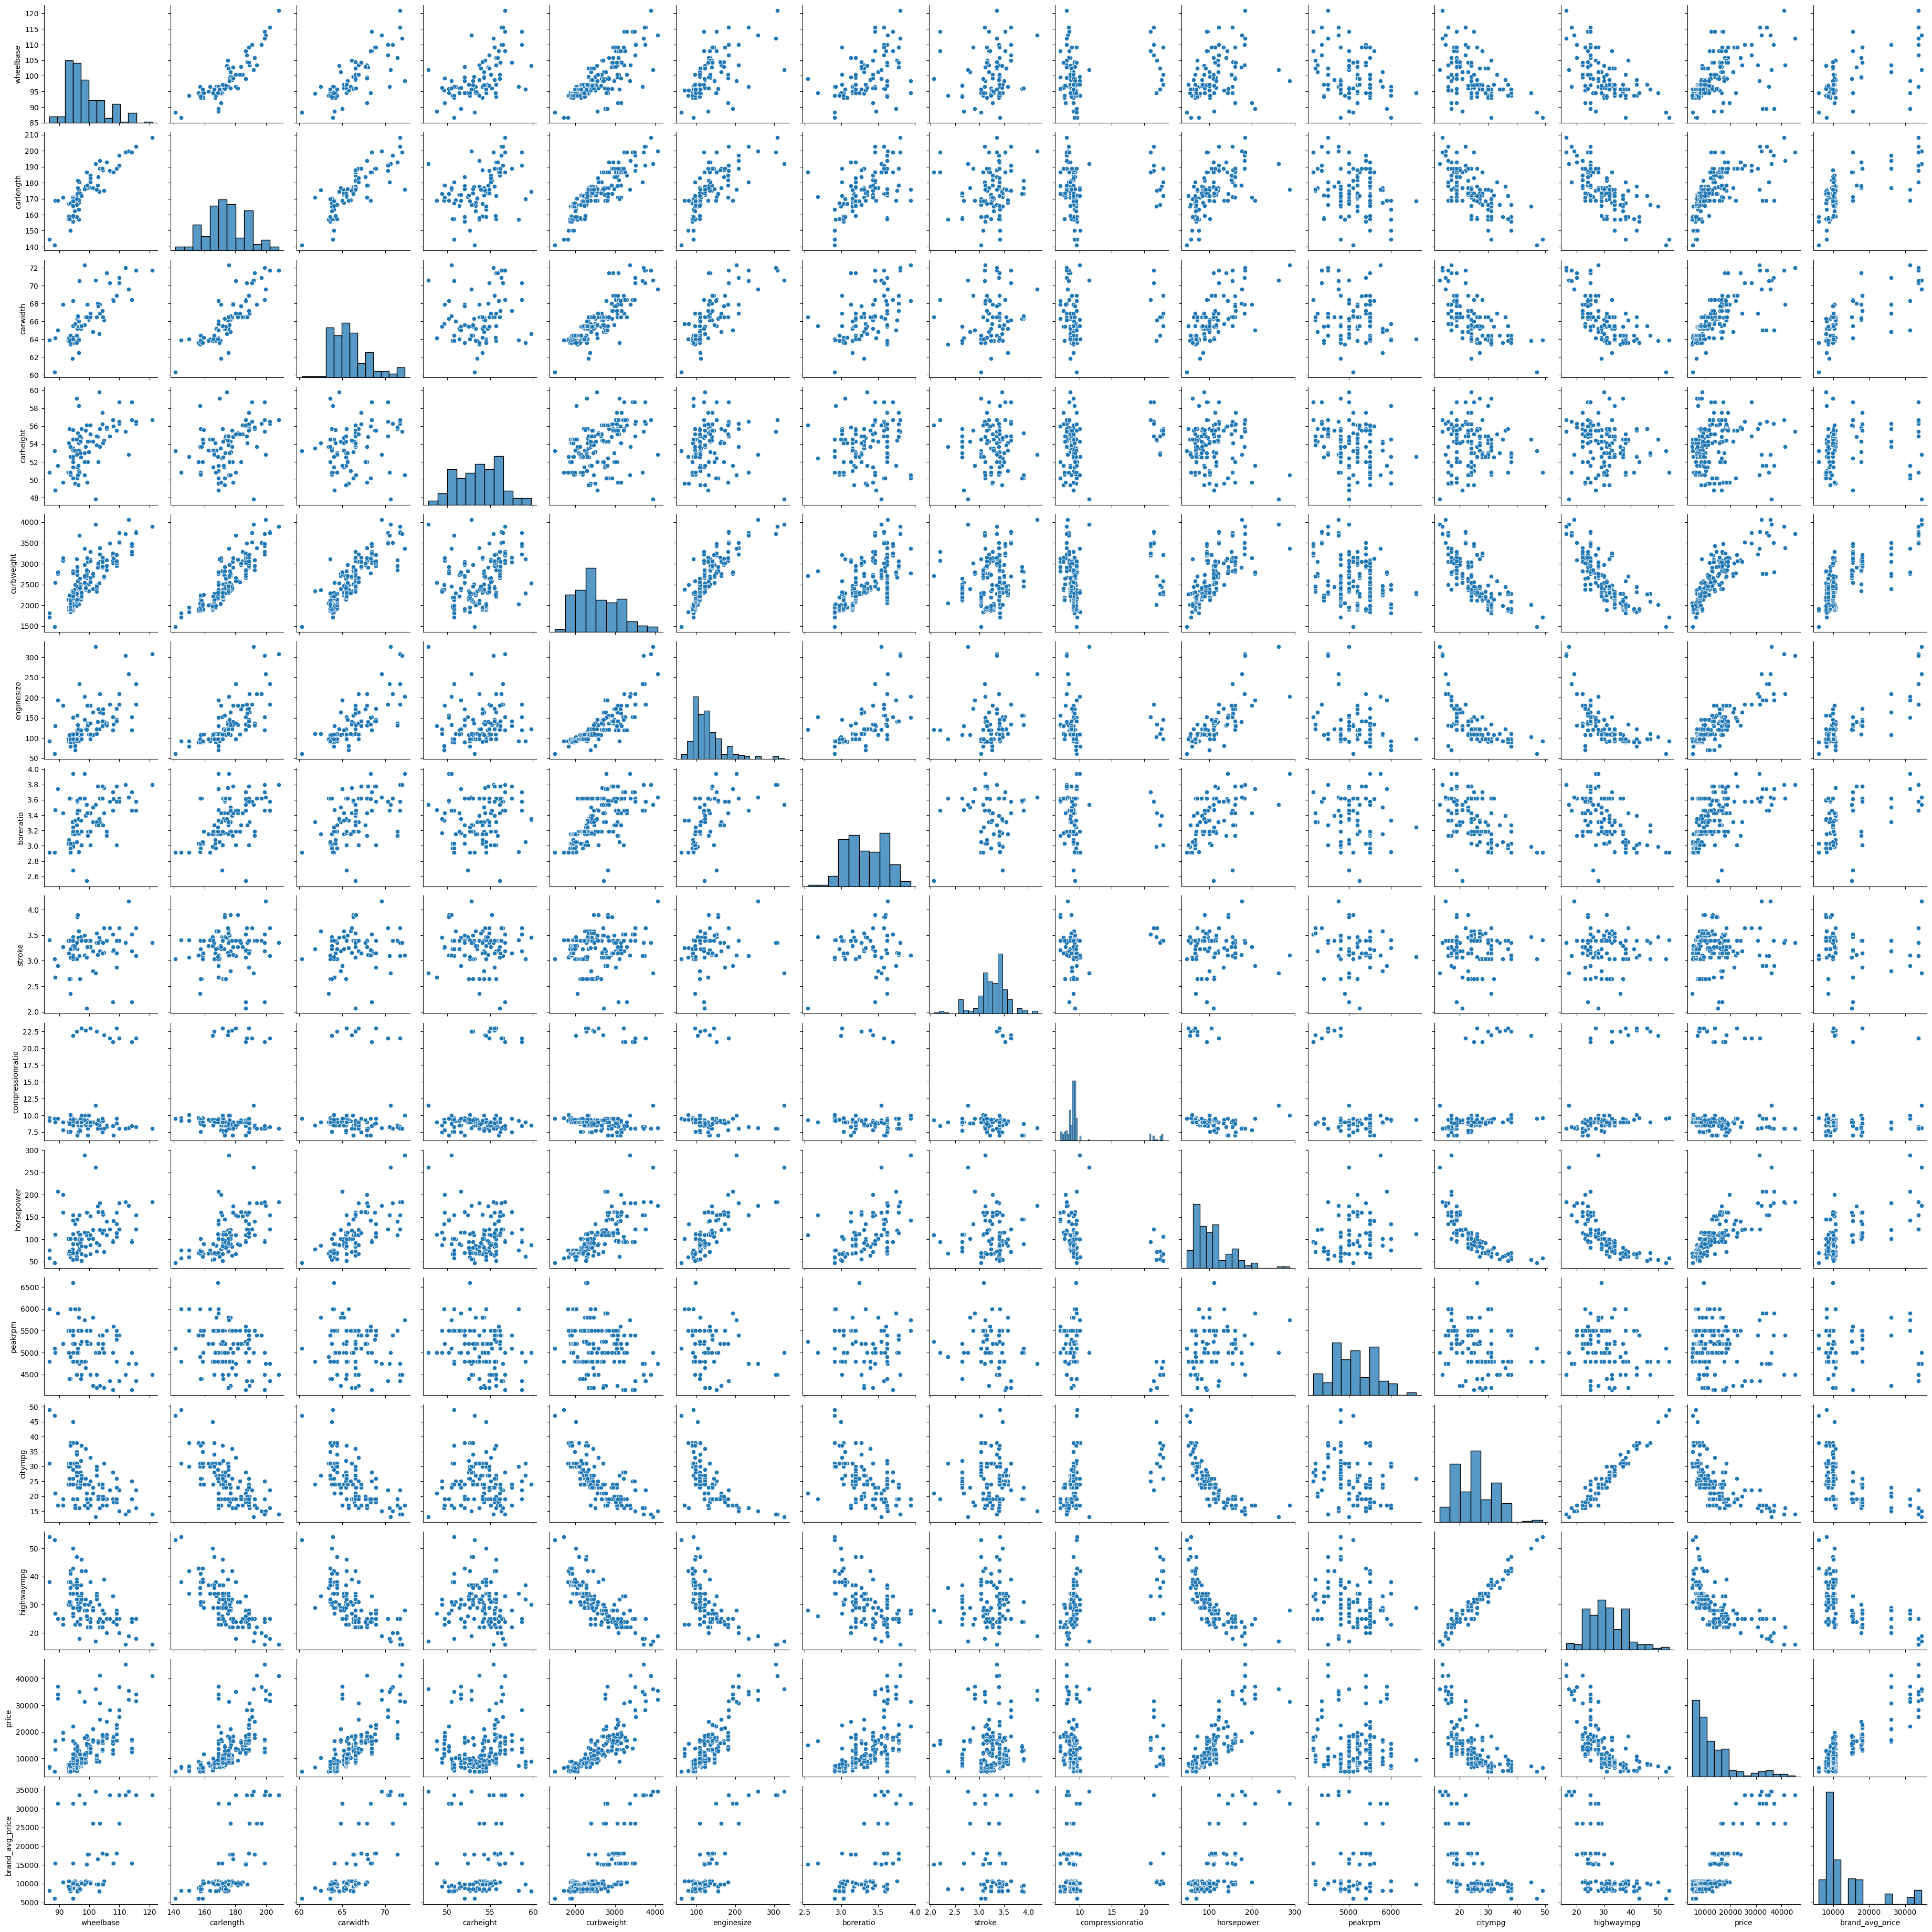

In [54]:
# Enter your code and run the cell
sns.pairplot(data)
plt.show()

## Prueba de supuestos para la regresión lineal 
Dado que ajustamos un modelo lineal, asumimos que la relación entre el objetivo (precio) y otras características es lineal.

También esperamos que los errores, o residuos, sean fluctuaciones puramente aleatorias alrededor de la línea verdadera; en otras palabras, la variabilidad de la variable de respuesta (dependiente) no aumenta al aumentar el valor de la variable predictora (independiente). Este es el supuesto de varianza igual, también conocido como **homocedasticidad**.

También asumimos que las observaciones son independientes entre sí **(sin multicolinealidad)** y que no hay correlación entre las observaciones secuenciales.

Si observamos que una de estas suposiciones en el conjunto de datos no se cumple, es más probable que las demás, mencionadas anteriormente, también se incumplan. Afortunadamente, podemos comprobar y corregir estas suposiciones con algunas técnicas únicas.

Ahora, analicemos brevemente cada uno de estos supuestos en nuestro ejemplo.

### 1. Supuesto de linealidad 
La regresión lineal requiere que la relación entre la variable independiente y la variable dependiente sea lineal. Podemos comprobar esta suposición con algunos diagramas de dispersión y rectas de regresión.

Comenzaremos con las características 'enginesize' y 'horsepower'.

3


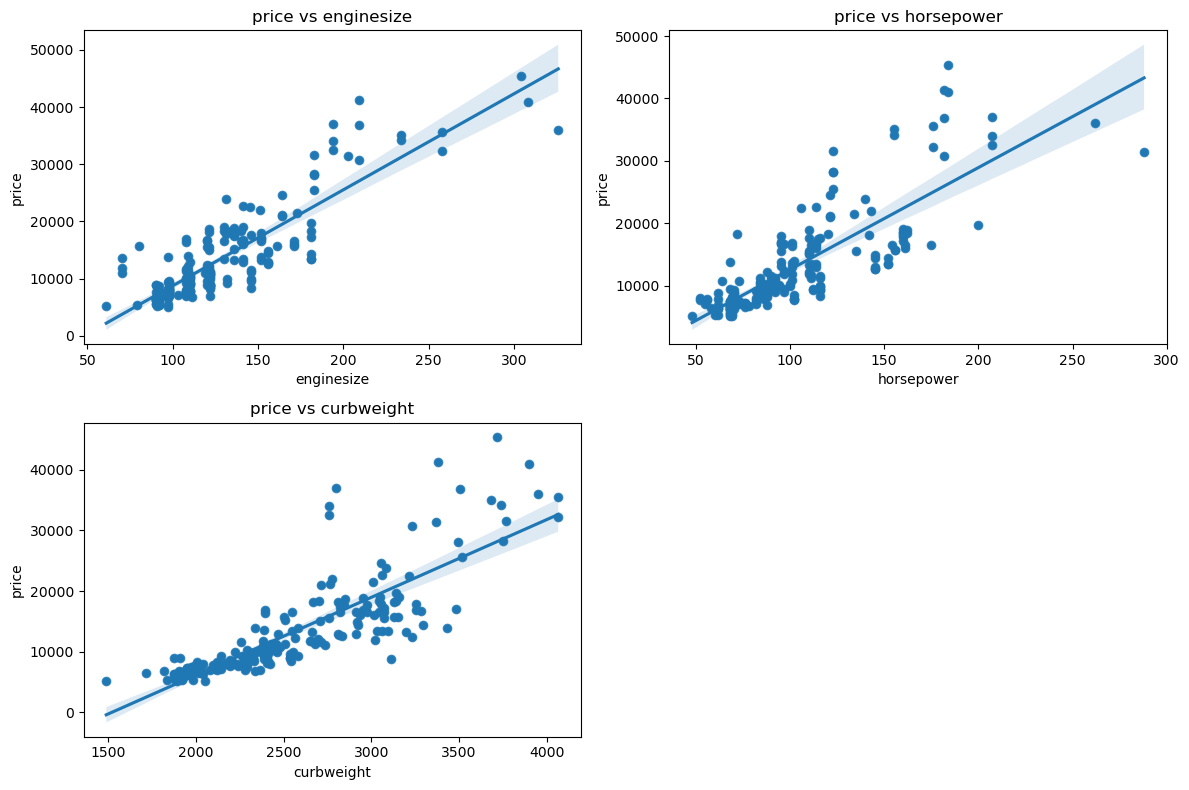

In [56]:
import sys
# Agregar la ruta donde se encuentra tu archivo .py
sys.path.append(r"C:\Users\LENOVO\Downloads\Latex\CursosML\IBM")

# Ahora puedes importar tu módulo
import Funciones_ML as ML
ML.plot_scatter(data, x_cols=['enginesize','horsepower','curbweight'], y_col='price')

## Ejercicio 3 
En este ejercicio, grafique cualquier otra característica numérica, utilizando la función `regplot()` de **seaborn**  , para ver si existe alguna relación lineal entre la característica y el 'price'.

<Axes: xlabel='curbweight', ylabel='price'>

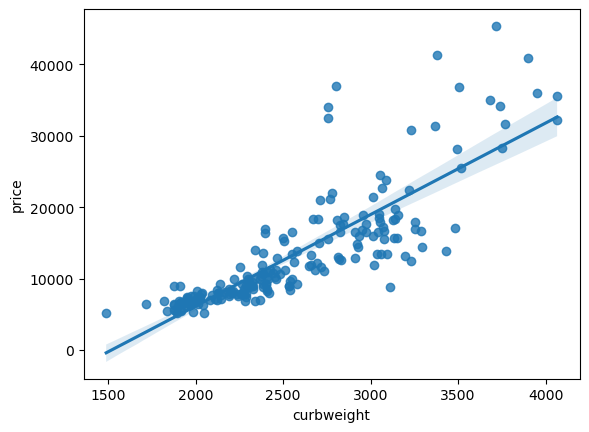

In [58]:
sns.regplot(x=data.curbweight, y=data.price, data=data)

### 2. *Homocedasticidad*
El supuesto de **homocedasticidad (varianza constante)** es crucial para los modelos de regresión lineal. La homocedasticidad describe una situación en la que el término de error, la varianza, el ruido o la perturbación aleatoria en la relación entre las variables independientes y la variable dependiente es el mismo en todos los valores de la variable independiente. En otras palabras, existe una varianza constante en la variable de respuesta a medida que aumenta la variable predictora. Si el ruido no es el mismo en todos los valores de una variable independiente, se denomina **heterocedasticidad** , lo opuesto a la **homocedasticidad.**


El supuesto de **homocedasticidad (varianza constante)** es crucial para los modelos de regresión lineal. La homocedasticidad describe una situación en la que el **término de error** $ \varepsilon_i $ tiene **la misma varianza** para todos los valores de la variable independiente $ X $:

$
\text{Var}(\varepsilon_i) = \sigma^2 \quad \forall i
$

Si la varianza de los errores cambia con $ X $, se llama **heterocedasticidad**:

$
\text{Var}(\varepsilon_i) = \sigma_i^2 \quad \text{y depende de } X_i
$

e }

### Ejemplo Matemático

**Modelo de regresión lineal:**

$
Y_i = \beta_0 + \beta_1 X_i + \varepsilon_i
$

- Homocedasticidad: $ \text{Var}(\varepsilon_i) = 4 $
- Heterocedasticidad: $ \text{Var}(\varepsilon_i) = X_i $

### Ejemplo práctico

**Homocedasticidad:** Prediciendo el peso de una persona a partir de su altura dentro de un rango restringido (p. ej., adultos de 1.60 m a 1.80 m), la variabilidad del peso alrededor de la línea de regresión puede ser aproximadamente constante.

**Heterocedasticidad:** Prediciendo los ingresos a partir de los años de educación, donde personas con educación avanzada pueden tener ingresos mucho más dispersos que personas con menor educación, lo que genera una varianza creciente con 
$𝑋$


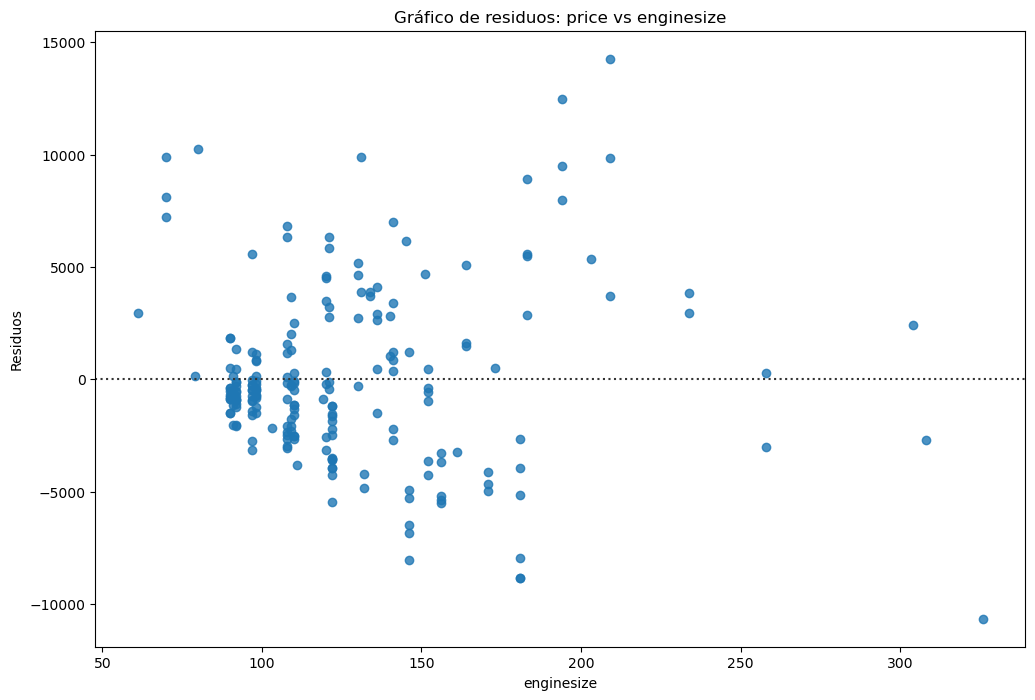

In [60]:
ML.plot_residuals(data, x_col= 'enginesize', y_col= 'price', figsize=(12,8))

Del gráfico anterior, se desprende que la varianza del error a lo largo de la línea verdadera no se dispersa de manera uniforme, sino en forma de embudo. Por lo tanto, es más probable que no se cumpla el supuesto de **homocedasticidad.**

### 3. Normalidad 
El análisis de regresión lineal requiere que la variable dependiente, 'price', tenga una distribución normal. Un histograma, un diagrama de caja o un diagrama QQ permiten comprobar si la variable objetivo tiene una distribución normal. La **prueba de bondad de ajuste**, como la prueba de Kolmogorov-Smirnov, permite comprobar la normalidad de la variable dependiente. [Esta documentacion](https://towardsdatascience.com/normality-tests-in-python-31e04aa4f411)  contiene más información sobre el supuesto de normalidad.

Mostremos los tres gráficos para mostrar cómo se comporta nuestra variable objetivo, 'price'.

In [62]:
# Ahora puedes importar tu módulo
import Funciones_ML as ML


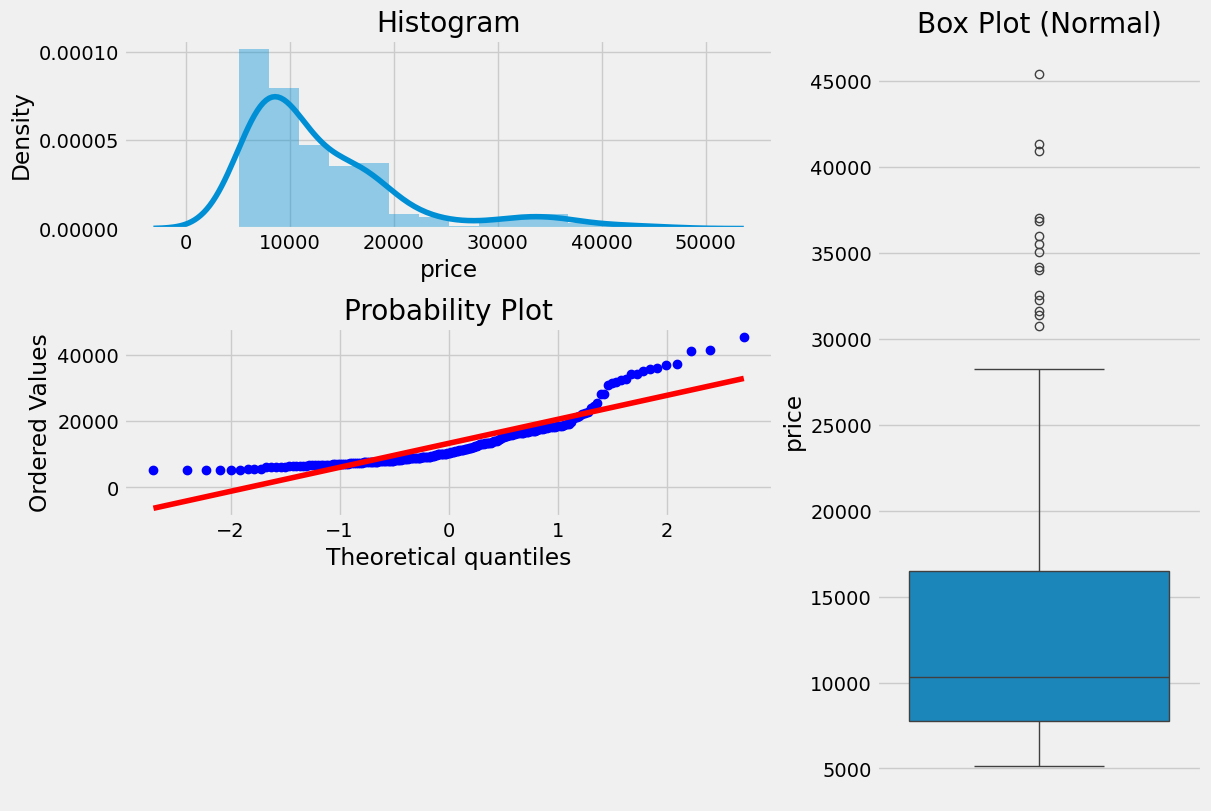

In [63]:
ML.plotting_3_chart(data, 'price', 'Normal')

Estos tres gráficos anteriores pueden decirnos mucho sobre nuestra variable objetivo:

* Nuestra variable objetivo, 'price', no tiene una distribución normal
* Nuestra variable objetivo está **sesgada hacia la derecha**
* Hay algunos valores atípicos en la variable

El gráfico sesgado a la derecha indica que la mayoría de los precios del conjunto de datos se encuentran en el extremo inferior (por debajo de 15 000). El valor «máximo» está muy alejado del estadístico cuantil del 75 \%. Todos estos gráficos muestran que no se cumple el supuesto de precisión en el modelado de regresión lineal.

A continuación, realizaremos la transformación logarítmica para corregir nuestra variable objetivo y hacer que tenga una distribución más normal.

Pero primero, guardaremos los datos que hemos cambiado hasta ahora, en el marco 'previous_data'.

In [65]:
previous_data = data.copy()

### Log Transformation


In [67]:
# Ahora puedes importar tu módulo
import Funciones_ML as ML

We can also check statistically if the target is normally distributed, using `normaltest()` function. If the p-value is large (>0.05), the target variable is normally distributed.


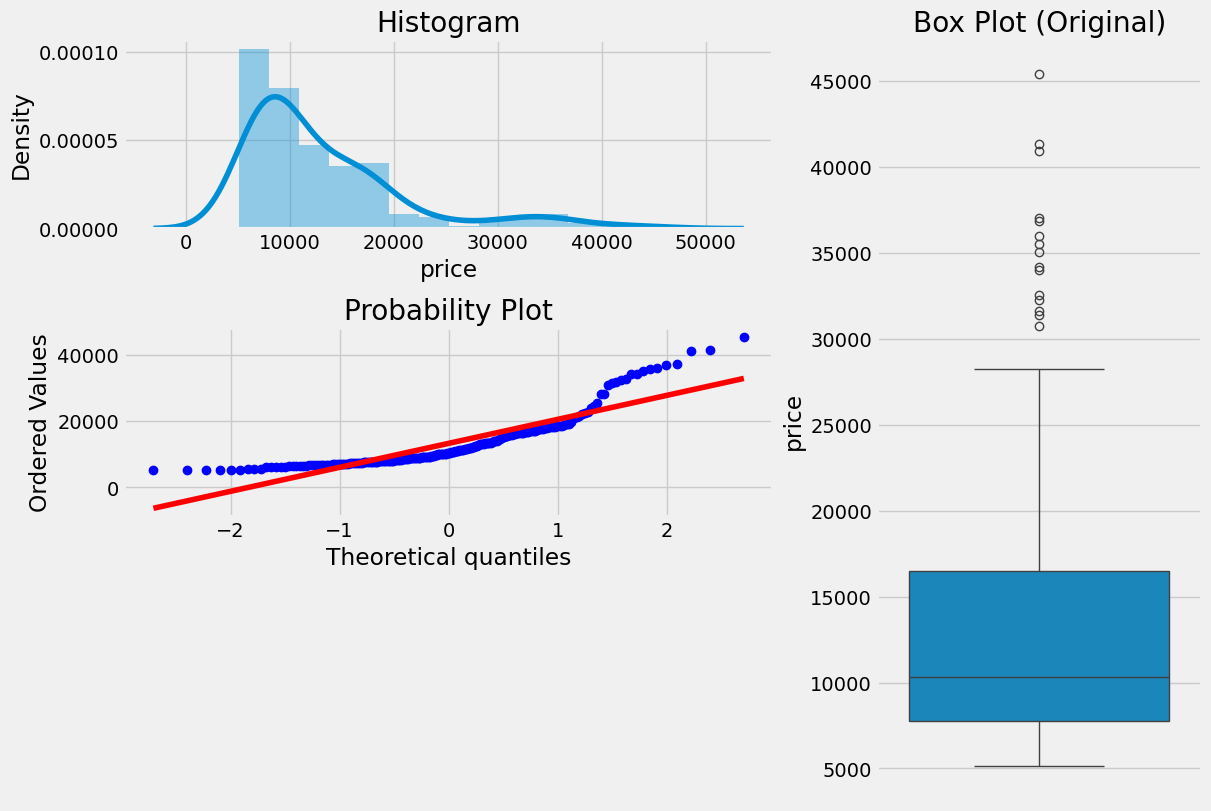

In [69]:
ML.plotting_3_chart(data, 'price', 'Original')

In [70]:
ML.verificar_normalidad(previous_data, 'price')

"La variable 'price' NO sigue una distribución normal (p=1.578344501676757e-17)."

Como podemos ver, el valor p es muy pequeño, por lo que no tiene una distribución normal.

Ahora podemos intentar **transformar** nuestros datos para que se vean más distribuidos normalmente. Podemos usar las funciones **np.log()**  para realizar la transformación logarítmica. Funciona mejor con números pequeños y, por lo tanto, proporciona resultados más precisos. Esta [documentacion](https://numpy.org/doc/stable/reference/generated/numpy.log.html) contiene más información sobre la transformación logarítmica.

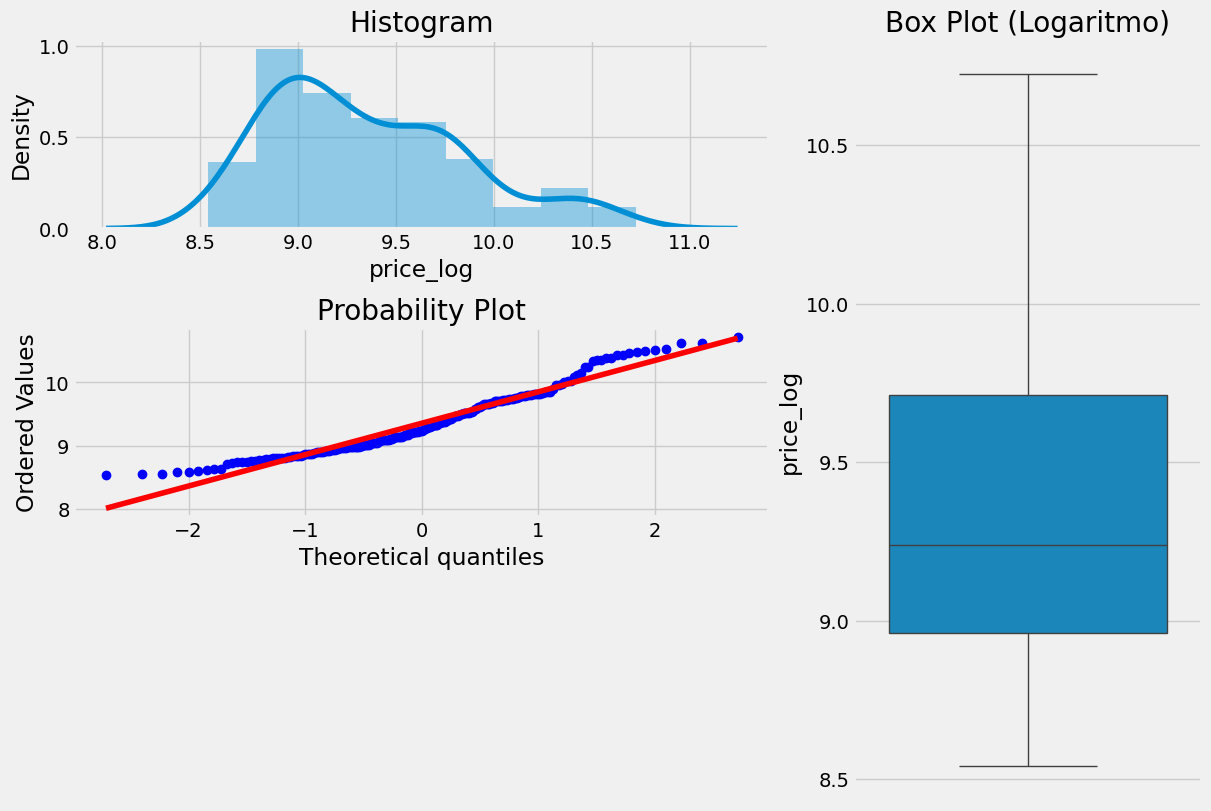

In [72]:
data['price_log'] = np.log(data['price']) #Aplicamos logaritmo a nuestra variables
ML.plotting_3_chart(data, 'price_log', 'Logaritmo')

Let's check our p-value, after the transformation. 


In [74]:
normaltest(data.price_log.values)

NormaltestResult(statistic=14.10341345775947, pvalue=0.0008659297880185564)

Como podemos ver, el método logarítmico transformó la distribución del precio del automóvil en una curva de campana más simétrica. Aún no es perfecta, pero **se acerca mucho más a una distribución normal.**

Existen otras maneras de corregir los datos sesgados. Por ejemplo, la Transformación de Raíz Cuadrada ( `np.sqrt`) y la Transformación de Box-Cox ( `stats.boxcox` de la biblioteca `scipy stats`). Para obtener más información sobre estos dos métodos, consulte este [articulo](https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45).

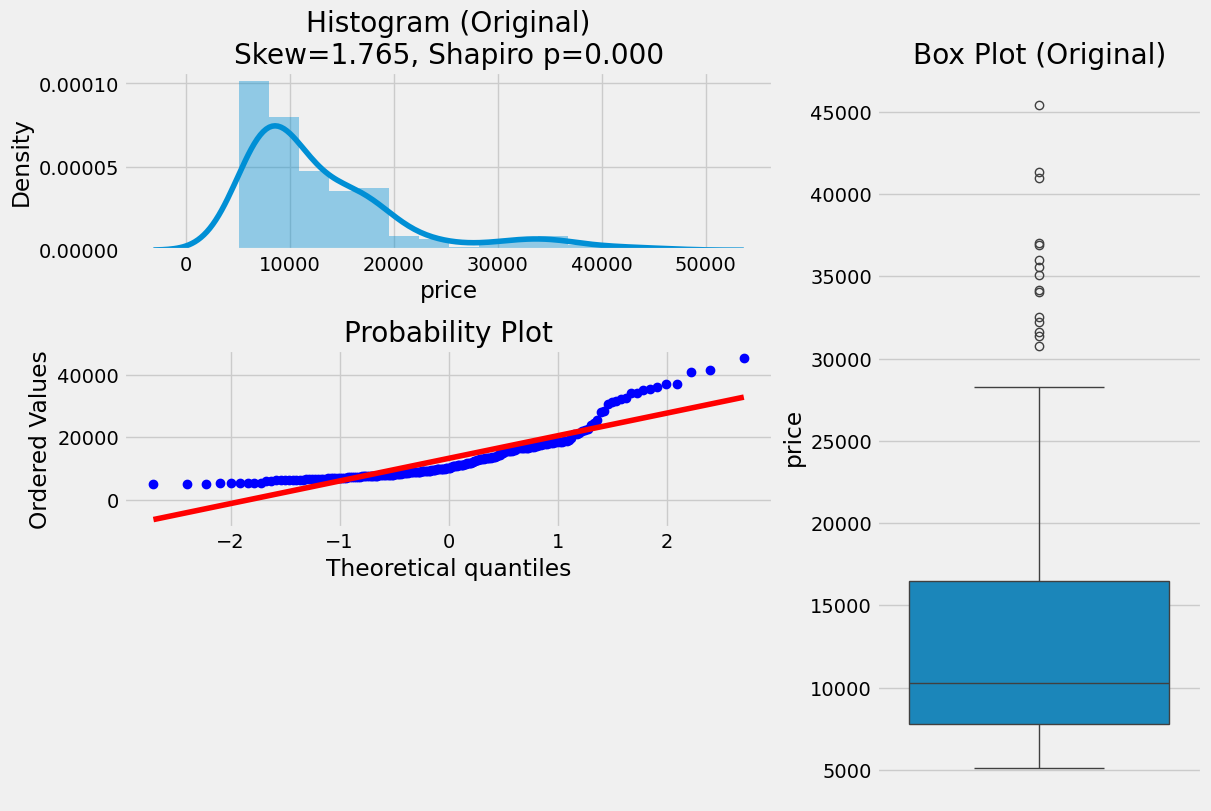

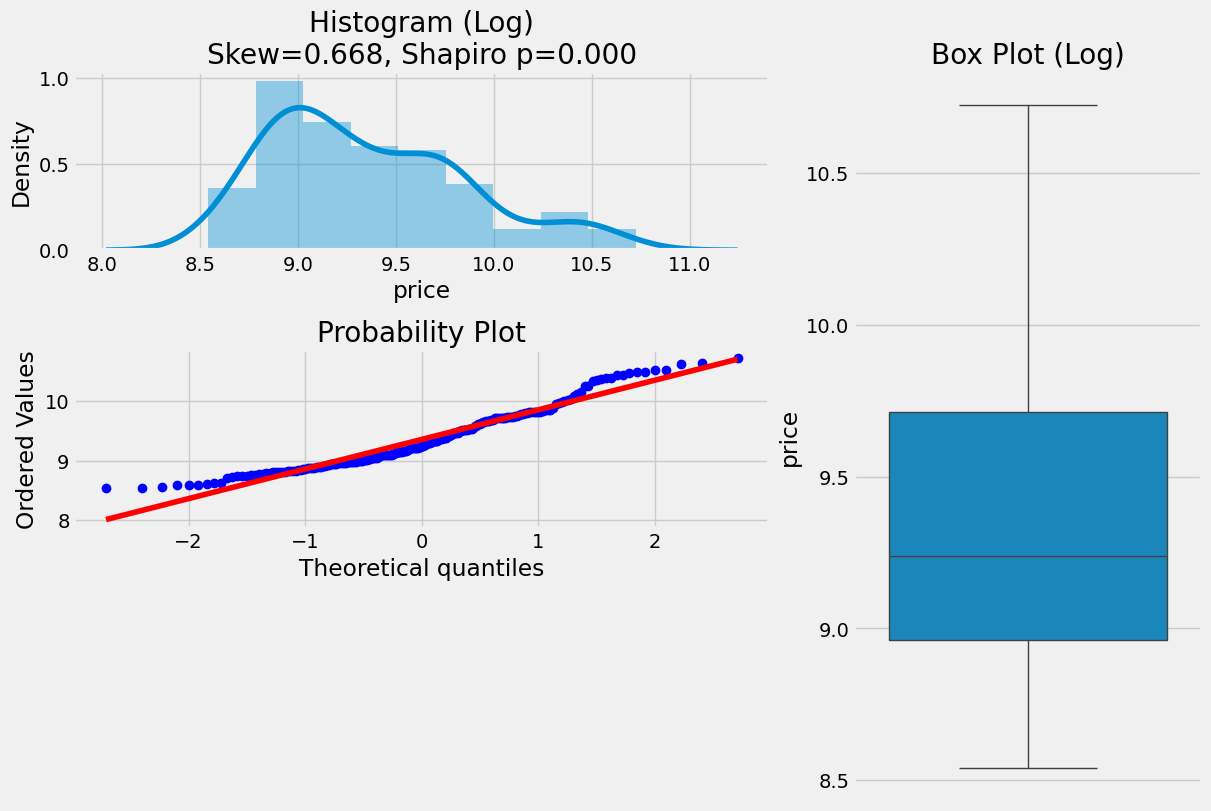

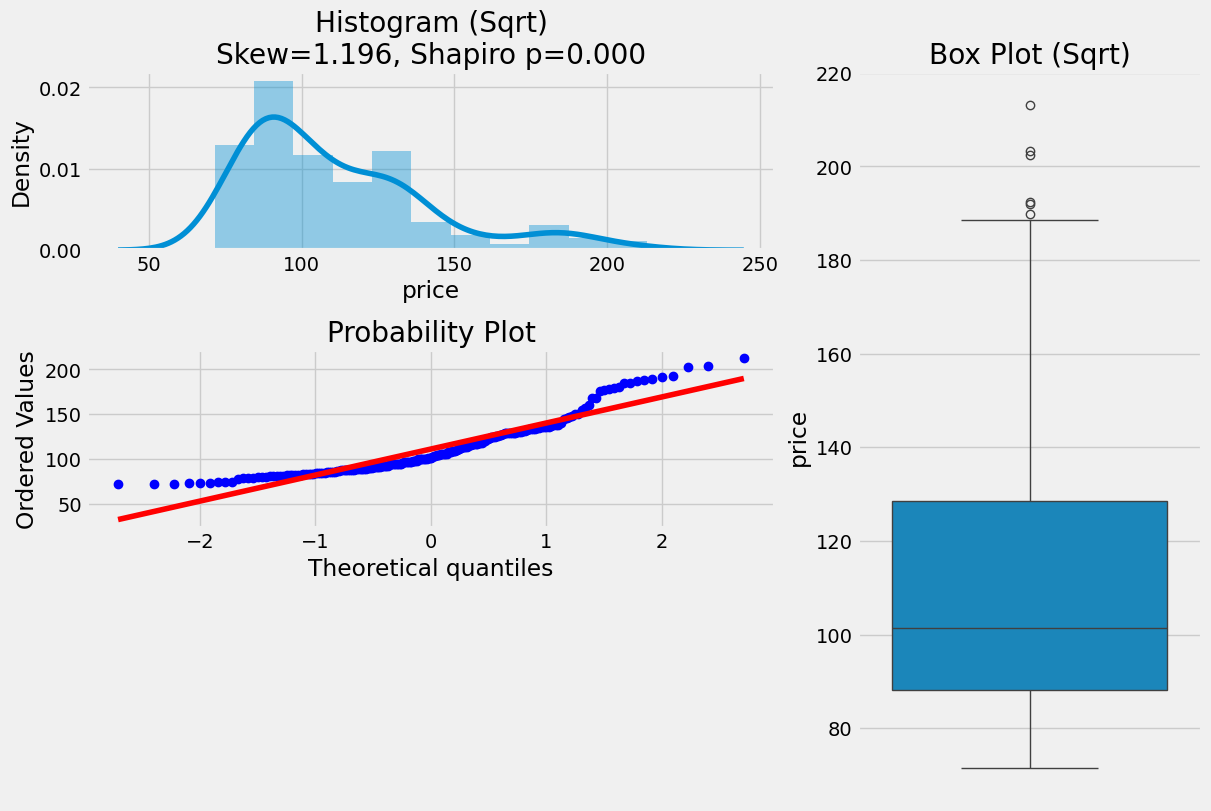

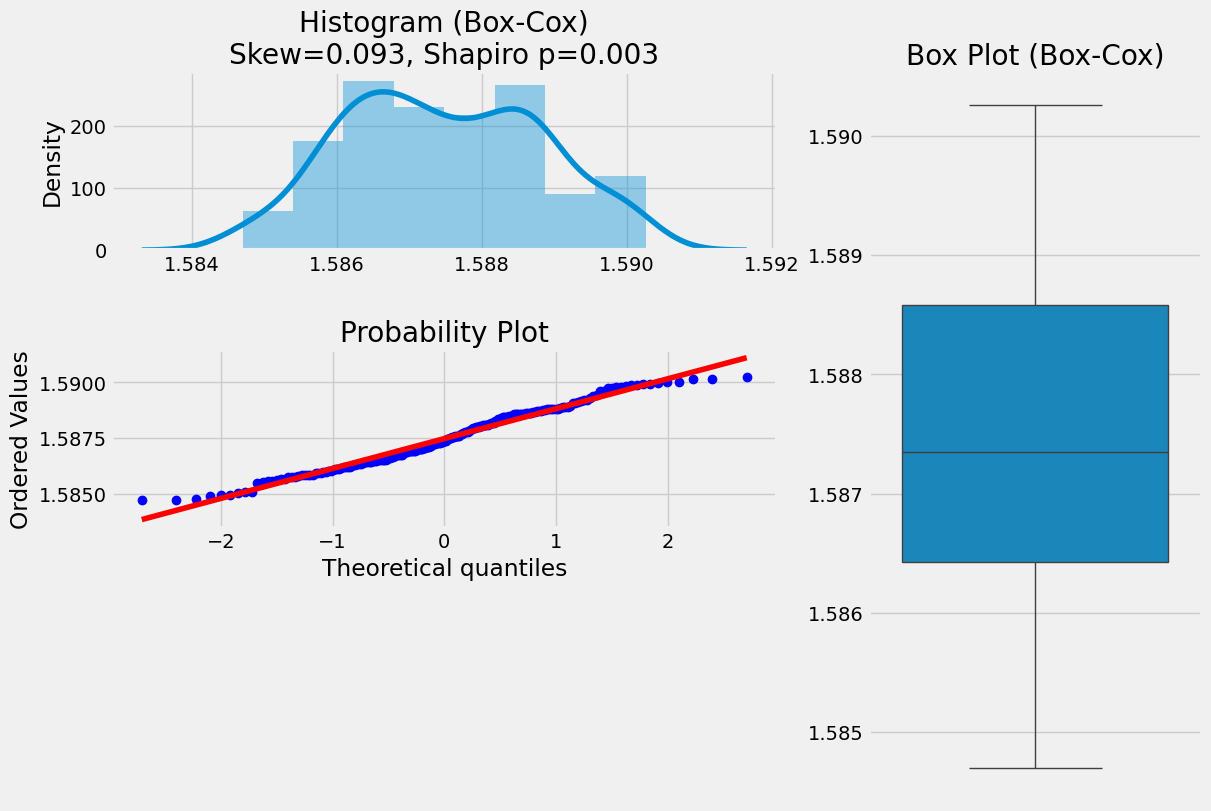

In [76]:
ML.plot_transformed_distributions_log_sqrt_boxcox(data, 'price')

## Ejercicio 4 
Utilice la función `boxcox()` para realizar otra transformación en los datos originales sin transformar (previous_data). Utilice la función `normaltest()` para comprobar las estadísticas.

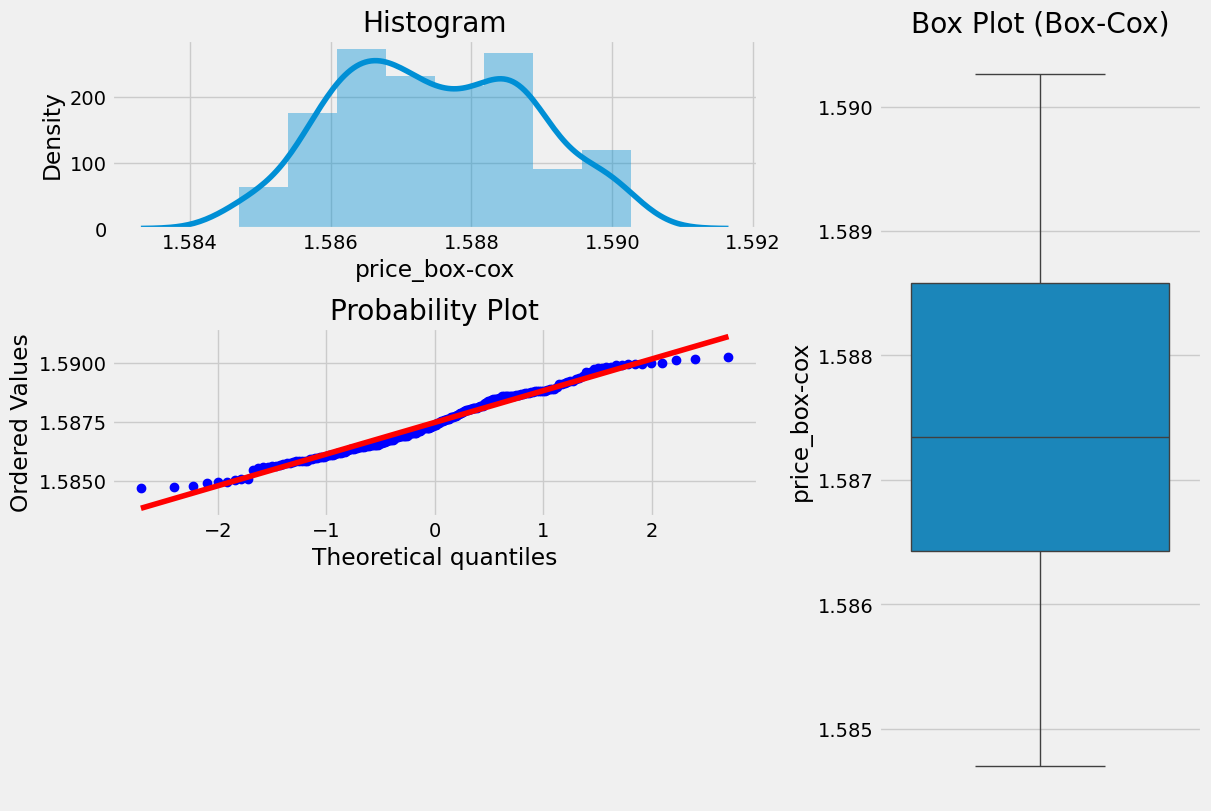

In [78]:
cp_result = boxcox(data['price'])

data['price_box-cox'] = cp_result[0] #Aplicamos box-cox a nuestra variable 'price'
ML.plotting_3_chart(data, 'price_box-cox', 'Box-Cox')

In [79]:
ML.verificar_normalidad(data, 'price_box-cox')

"La variable 'price_box-cox' NO sigue una distribución normal (p=0.00023321006918393855)."

Cuanto mayor sea el valor p, más cercana será la distribución a la normalidad. En nuestro caso, un valor p = 0,0,00023321005129893173 es muy pequeño (<0,05), por lo que la variable objetivo aún no se distribuye normalmente.

## Ejercicio 5
Utilice la función  `np.sqrt` 

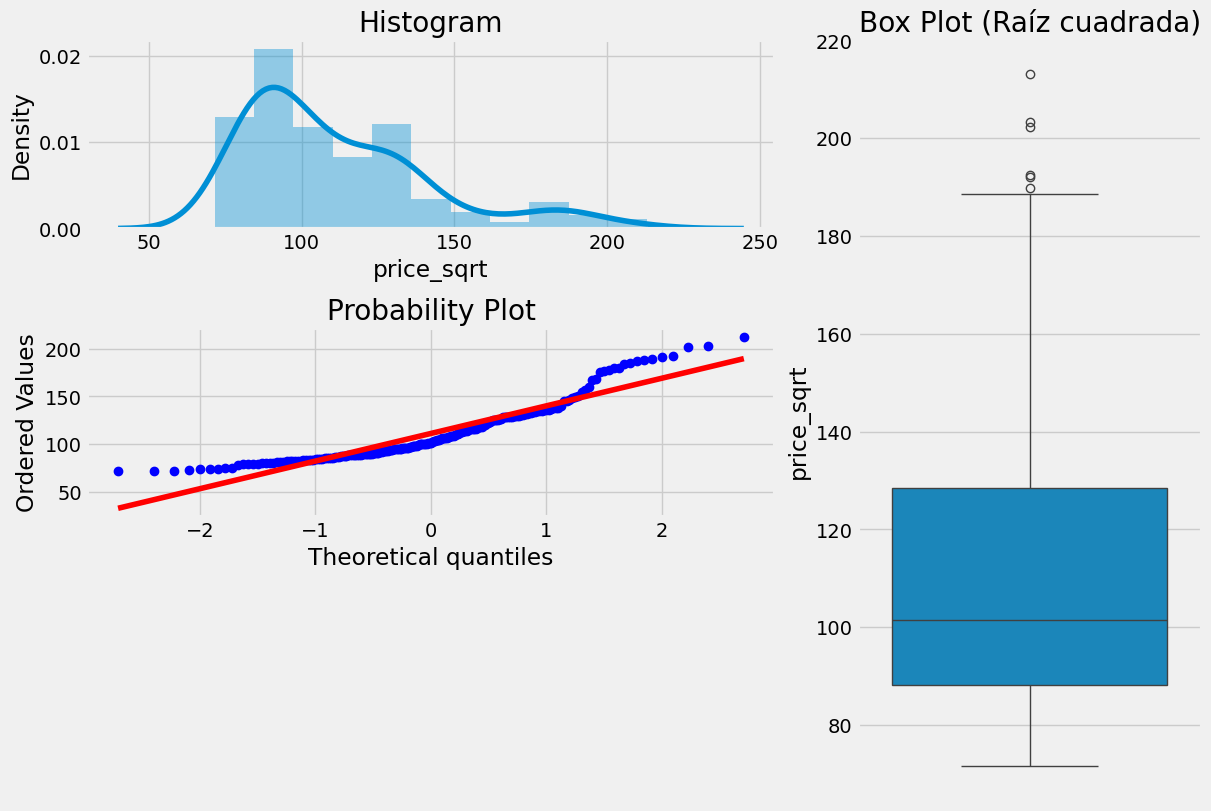

In [82]:
data['price_sqrt'] = np.sqrt(data['price']) #Aplicamos logaritmo a nuestra variables
ML.plotting_3_chart(data, 'price_sqrt', 'Raíz cuadrada')

In [83]:
ML.verificar_normalidad(data,'price_sqrt')

"La variable 'price_sqrt' NO sigue una distribución normal (p=1.7826006335391704e-09)."

Tras aplicar la transformación de raíz cuadrada a la variable objetivo, observamos —tanto por el p-valor (1.78×10⁻⁹) como por las gráficas anteriores— que la distribución resultante sigue sin ajustarse a una distribución normal.

### 4. Multicolinealidad

La **multicolinealidad** se produce cuando existe una fuerte correlación entre las variables independientes. La regresión lineal o multilineal requiere que las variables independientes tengan características similares o muy pocas. La multicolinealidad puede generar diversos problemas, entre ellos:

- El efecto de las variables predictoras estimadas por nuestra regresión dependerá de qué otras variables se incluyan en nuestro modelo.
- Los predictores pueden tener resultados muy diferentes dependiendo de las observaciones en nuestra muestra, y pequeños cambios en las muestras pueden resultar en efectos estimados muy diferentes.
- Con una multicolinealidad muy alta, la matriz inversa, los cálculos de la computadora pueden no ser precisos.
- Ya no podemos interpretar un coeficiente de una variable porque no existe ningún escenario en el que una variable pueda cambiar sin un cambio condicional en otra variable.
  
Usar la funcion `heatmap()`   es una excelente manera de identificar si existe multicolinealidad . La mejor manera de determinarla es usar métodos de **regularización como Ridge o Lasso** , que presentaremos en el laboratorio de **Regularización.**

## Exercise 5
Use the `heatmap()` do display all correlation factors of the numeric variables. Do you see any correlations between the independent features?


In [87]:
data= data.drop(columns=['price_box-cox', 'price_sqrt']) #Eliminamos las columnas anteriormente creadas

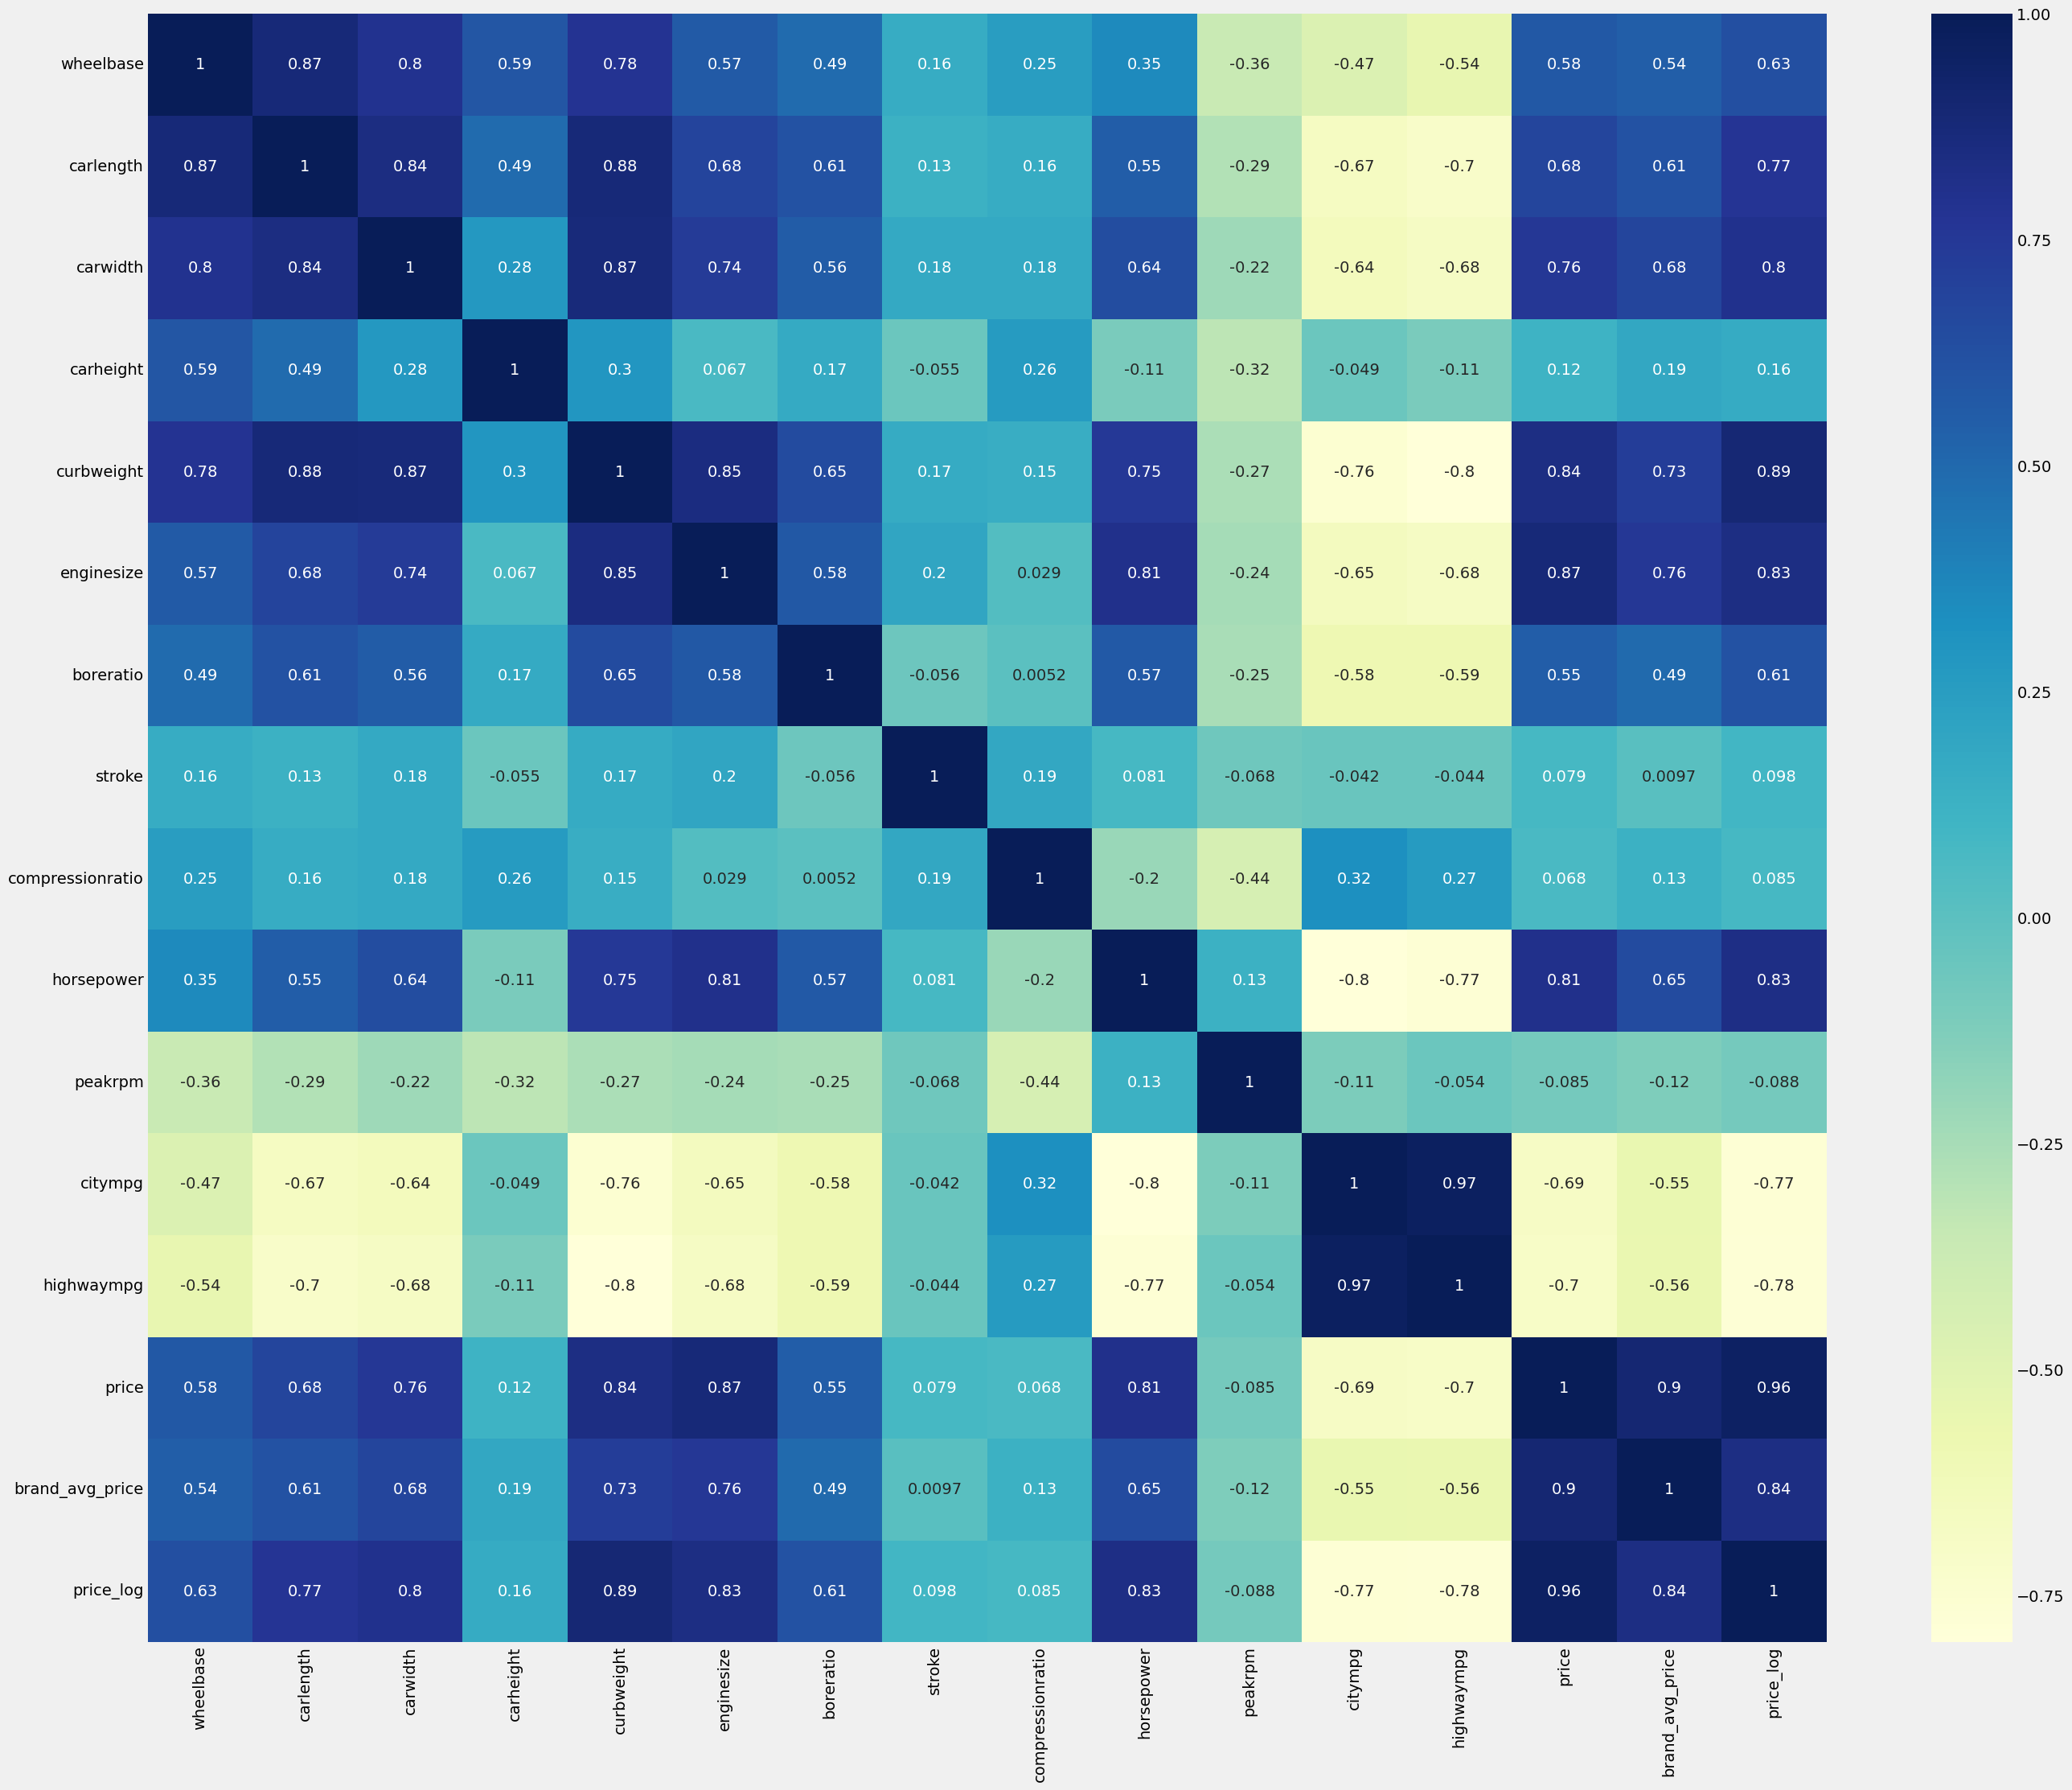

In [88]:
num = data.select_dtypes(include = ['int64', 'float64'])
plt.figure(figsize = (30, 25))
sns.heatmap(num.corr(), annot = True, cmap="YlGnBu")
plt.show()   
    

Observación. Como podemos ver, la multicolinealidad aún existe en varias características. Sin embargo, las conservaremos por ahora para fines de aprendizaje y dejaremos que los modelos (por ejemplo, los modelos de regularización como Lasso y Ridge, en el próximo laboratorio) realicen la limpieza más adelante.

## **Linear Regression Model**


List of significant variables after Exploratory Data Analysis :

Numerical:

- Curb weight (peso en vacío)
- Car length (longitud del automóvil)
- Car width (anchura del automóvil)
- Engine size (tamaño del motor / cilindrada)
- Bore ratio (relación de diámetro del cilindro)
- Horse power (caballos de fuerza / potencia)
- Wheel base (distancia entre ejes)
- City mpg (millas por galón en ciudad / consumo en ciudad)
- Highway mpg (millas por galón en carretera / consumo en carretera)


Categorical:

- Engine type (tipo de motor)
- Fuel type (tipo de combustible)
- Car body (carrocería)
- Aspiration (tipo de aspiración del motor — natural, turbo, etc.)
- Cylinder number (número de cilindros)
- Drive wheel (tracción — delantera, trasera, 4x4)
-Brand category (categoría de la marca)

Vamos a colocar todas las características seleccionadas en un marco de datos.


In [92]:
data.columns

Index(['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
       'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight',
       'curbweight', 'enginetype', 'cylindernumber', 'enginesize',
       'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg', 'price', 'brand', 'brand_avg_price',
       'brand_category', 'price_log'],
      dtype='object')

Considerando lo anterior y observando que la transformación logarítmica de la variable dependiente aproxima mejor una distribución normal, procedemos a aplicar dicha transformación, es decir: **data.price = data.price_log**

In [94]:
data.price = data.price_log #Nos quedamos con los valores de log

In [95]:
columns=['price', 'fueltype', 'aspiration','carbody', 'drivewheel','wheelbase', 'brand_category',
                  'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'boreratio','horsepower', 'carlength','carwidth','citympg','highwaympg']



selected = data[columns]
selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           205 non-null    float64
 1   fueltype        205 non-null    object 
 2   aspiration      205 non-null    object 
 3   carbody         205 non-null    object 
 4   drivewheel      205 non-null    object 
 5   wheelbase       205 non-null    float64
 6   brand_category  205 non-null    object 
 7   curbweight      205 non-null    int64  
 8   enginetype      205 non-null    object 
 9   cylindernumber  205 non-null    object 
 10  enginesize      205 non-null    int64  
 11  boreratio       205 non-null    float64
 12  horsepower      205 non-null    int64  
 13  carlength       205 non-null    float64
 14  carwidth        205 non-null    float64
 15  citympg         205 non-null    int64  
 16  highwaympg      205 non-null    int64  
dtypes: float64(5), int64(5), object(7)


In [96]:
selected.head(2)

,price,fueltype,aspiration,carbody,drivewheel,wheelbase,brand_category,curbweight,enginetype,cylindernumber,enginesize,boreratio,horsepower,carlength,carwidth,citympg,highwaympg
0,9.510075,gas,std,convertible,rwd,88.6,Mid_Range,2548,dohc,four,130,3.47,111,168.8,64.1,21,27
1,9.711116,gas,std,convertible,rwd,88.6,Mid_Range,2548,dohc,four,130,3.47,111,168.8,64.1,21,27


Podemos encontrar las columnas categóricas iterando a través del ```dtypes```  atributo

In [98]:
categorical_columns = [key for key, value in selected.dtypes.items() if value == 'O']
categorical_columns

['fueltype',
 'aspiration',
 'carbody',
 'drivewheel',
 'brand_category',
 'enginetype',
 'cylindernumber']

## Ejercicio 6 
Busque los nombres de las ```columnas``` numéricas usando la lista columnsy asígnelos a la lista ```columnas numericas```.

In [100]:
# Enter your code and run the cell
numeric_columns=list(set(columns)-set(categorical_columns))
numeric_columns

['wheelbase',
 'highwaympg',
 'citympg',
 'carwidth',
 'curbweight',
 'enginesize',
 'carlength',
 'price',
 'boreratio',
 'horsepower']

We can split the data into the features ```X``` and target ```y```.


In [102]:
X = selected.drop("price", axis=1)
X.head()


,fueltype,aspiration,carbody,drivewheel,wheelbase,brand_category,curbweight,enginetype,cylindernumber,enginesize,boreratio,horsepower,carlength,carwidth,citympg,highwaympg
0,gas,std,convertible,rwd,88.6,Mid_Range,2548,dohc,four,130,3.47,111,168.8,64.1,21,27
1,gas,std,convertible,rwd,88.6,Mid_Range,2548,dohc,four,130,3.47,111,168.8,64.1,21,27
2,gas,std,hatchback,rwd,94.5,Mid_Range,2823,ohcv,six,152,2.68,154,171.2,65.5,19,26
3,gas,std,sedan,fwd,99.8,Mid_Range,2337,ohc,four,109,3.19,102,176.6,66.2,24,30
4,gas,std,sedan,4wd,99.4,Mid_Range,2824,ohc,five,136,3.19,115,176.6,66.4,18,22


In [103]:
y = selected["price"].copy()
y.head()

0    9.510075
1    9.711116
2    9.711116
3    9.543235
4    9.767095
Name: price, dtype: float64

Before we used one-hot encoding to deal with the categorical data, let's examine the distribution of the categorical variables:


In [105]:
for column in categorical_columns:
    print("\n" + "-"*40)
    print(f"Column: {column}")
    print("-"*40)
    print(X[column].value_counts())


----------------------------------------
Column: fueltype
----------------------------------------
fueltype
gas       185
diesel     20
Name: count, dtype: int64

----------------------------------------
Column: aspiration
----------------------------------------
aspiration
std      168
turbo     37
Name: count, dtype: int64

----------------------------------------
Column: carbody
----------------------------------------
carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

----------------------------------------
Column: drivewheel
----------------------------------------
drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64

----------------------------------------
Column: brand_category
----------------------------------------
brand_category
Budget       95
Mid_Range    86
Luxury       24
Name: count, dtype: int64

----------------------------------------
Column: enginetype
---------------------

Observamos que muchas características categóricas tienen pocas o una sola ocurrencia. Por ejemplo, vemos que  ```three```, ```twelve``` solo ocurre una vez en la columna ```cylindernumber```. Por lo tanto, si los componentes de la **codificación one-hot** se construyen con los datos de entrenamiento y la muestra de la columna ```cylindernumber``` no incluye three o twelve, se obtendrá un error. **Por lo tanto, debemos dividir los datos antes de la transformación.** Esto es correcto, ya que **la codificación one-hot es una transformación determinista,** pero para otras transformaciones, como la estandarización, los parámetros deben estimarse con los datos de entrenamiento y luego aplicarse a los datos de prueba.

## OneHotEncoder

Utilizaremos los siguientes módulos:

In [107]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

Para realizar la codificación one-hot, utilizamos la **clase**  ```ColumnTransformer``` , esto permite transformar diferentes columnas o subconjuntos de columnas por separado.

La entrada es la siguiente:

Este `transformerslist` es el número de tuplas. La lista de `(name, transformer, columns)` tuplas especifica los objetos transformadores que se aplicarán a los subconjuntos de datos.

-  `name` : Nombre de la operación que se puede utilizar más adelante
-  `transformer` : El estimador debe soportar ajuste y transformación, en este caso utilizaremos `OneHotEncoder()`
-  `‘drop’`:Para eliminar las columnas
-  `‘passthrough’`: Para pasarlos a través de datos no transformados
-  `remainder`: especifica que las columnas que no se transforman se configuran como passthrough. Se combinan en la salida y se descartan las columnas no especificadas.

  
Aplicamos ```fit_transform()``` para transformar los datos.

In [109]:
one_hot = ColumnTransformer(transformers=[("one_hot", OneHotEncoder(), categorical_columns) ],remainder="passthrough")
X=one_hot.fit_transform(X)
type(X)

numpy.ndarray

Vemos que la salida es una matriz NumPy, así que obtendremos los nombres de las características del objeto ```one_hot```  mediante el método ```get_feature_names_out()``` . **La salida será el nombre de la característica con el prefijo del nombre del transformador.** Para la codificación one-hot, el prefijo también incluirá el nombre de la columna que generó esa característica.

In [111]:
names=one_hot.get_feature_names_out()
names

array(['one_hot__fueltype_diesel', 'one_hot__fueltype_gas',
       'one_hot__aspiration_std', 'one_hot__aspiration_turbo',
       'one_hot__carbody_convertible', 'one_hot__carbody_hardtop',
       'one_hot__carbody_hatchback', 'one_hot__carbody_sedan',
       'one_hot__carbody_wagon', 'one_hot__drivewheel_4wd',
       'one_hot__drivewheel_fwd', 'one_hot__drivewheel_rwd',
       'one_hot__brand_category_Budget', 'one_hot__brand_category_Luxury',
       'one_hot__brand_category_Mid_Range', 'one_hot__enginetype_dohc',
       'one_hot__enginetype_dohcv', 'one_hot__enginetype_l',
       'one_hot__enginetype_ohc', 'one_hot__enginetype_ohcf',
       'one_hot__enginetype_ohcv', 'one_hot__enginetype_rotor',
       'one_hot__cylindernumber_eight', 'one_hot__cylindernumber_five',
       'one_hot__cylindernumber_four', 'one_hot__cylindernumber_six',
       'one_hot__cylindernumber_three', 'one_hot__cylindernumber_twelve',
       'one_hot__cylindernumber_two', 'remainder__wheelbase',
       'remain

Let's strip out the prefix of the string. 


In [113]:
colunm_names=[name[name.find("_")+1:] for name in  [name[name.find("__")+2:] for name in names]]
colunm_names

['diesel',
 'gas',
 'std',
 'turbo',
 'convertible',
 'hardtop',
 'hatchback',
 'sedan',
 'wagon',
 '4wd',
 'fwd',
 'rwd',
 'category_Budget',
 'category_Luxury',
 'category_Mid_Range',
 'dohc',
 'dohcv',
 'l',
 'ohc',
 'ohcf',
 'ohcv',
 'rotor',
 'eight',
 'five',
 'four',
 'six',
 'three',
 'twelve',
 'two',
 'wheelbase',
 'curbweight',
 'enginesize',
 'boreratio',
 'horsepower',
 'carlength',
 'carwidth',
 'citympg',
 'highwaympg']

We can save the result as a dataframe to be used in other labs. 


In [130]:
df=pd.DataFrame(data=X,columns=colunm_names)
df.to_csv('cleaned_car_data.csv', index=False)



## Exercise 7
Write the lines of code  that performs same task as  ``ColumnTransformer`` using ``OneHotEncoder()``.


In [132]:
# Enter your code and run the cell
X_ = selected[categorical_columns+numeric_columns]


X_numeric=X_[numeric_columns].to_numpy()
X_categorical=OneHotEncoder().fit_transform(X_[categorical_columns]).toarray()
X_=np.concatenate((X_categorical,X_numeric), axis = 1)


## Exercise 8
Write the lines of code that performs same task as  ``ColumnTransformer`` using ``pd.get_dummies``.


In [134]:
# Define una función que convierte una columna categórica en variables dummy (one-hot encoding) y actualiza el DataFrame
def dummies(x, data):
    # Crea variables dummy para la columna 'x' del DataFrame 'data', eliminando la primera categoría para evitar multicolinealidad
    temp = pd.get_dummies(data[x], drop_first=True)
    
    # Concatena las nuevas columnas dummy al DataFrame original
    data = pd.concat([data, temp], axis=1)
    
    # Elimina la columna original que ya fue convertida a dummies
    data.drop([x], axis=1, inplace=True)
    
    # Devuelve el DataFrame actualizado
    return data


# Selecciona del DataFrame 'selected' únicamente las columnas categóricas y numéricas
X_ = selected[categorical_columns + numeric_columns]

# Inicializa un contador (aunque en este código no se está usando)
N_column = 0

# Recorre cada columna categórica para convertirla en dummies
for column in categorical_columns:
    # Muestra los valores únicos de la columna actual
    print(pd.unique(data[column]))
    
    # Convierte la columna categórica actual en dummies y actualiza el DataFrame X_
    X_ = dummies(column, X_)



['gas' 'diesel']
['std' 'turbo']
['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
['rwd' 'fwd' '4wd']
['Mid_Range' 'Luxury' 'Budget']
['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']
['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']


### División de datos. 

En el Módulo 2:
División de Datos y Validación Cruzada, profundizaremos en la división de datos para entrenamiento y prueba. Por ahora, usaremos la función `train_test_split()` de la biblioteca **sklearn.model_selection** para dividir nuestros datos en conjuntos de entrenamiento y prueba, utilizando el 30 % de los datos para pruebas.

In [136]:
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [138]:
X_train, X_test, y_train, y_test = train_test_split( df, y, test_size=0.30, random_state=0)

### Estandarizar los datos 
Estandarizamos las características eliminando la media y escalando a la varianza unitaria usando ```StandardScaler```, creamos un objeto ```StandardScaler```:

In [140]:
from sklearn.preprocessing import StandardScaler

In [142]:
ss=StandardScaler()
ss

StandardScaler()

We `fit` our training data, then we `transform` it.


In [144]:
X_train=ss.fit_transform(X_train)

### Linear Regression


Finally, we apply the `LinearRegression()` model and `fit()` our ```X``` and ```y``` data.


In [146]:
lm = LinearRegression()
lm.fit(X_train,y_train)


LinearRegression()

### Making Prediction


We will select some random data and apply the `predict()` function.


In [150]:
X_test=ss.transform(X_test)
car_price_predictions = lm.predict(X_test)
car_price_predictions

array([ 8.87368304,  9.76331696,  9.37619842,  8.20809049,  9.25745786,
        9.34999919,  8.689579  ,  8.80059779,  9.65140161,  8.81774326,
        9.8938222 , 11.24667301,  9.44950493,  9.481259  ,  8.72871162,
        9.27212737,  9.08262263,  9.59959188,  9.00069293,  8.7891817 ,
        9.23208309,  9.57673884,  9.1051809 ,  9.32525256,  9.77744006,
        8.84073863,  8.88827629,  9.61747728,  8.88440132,  8.87820614,
        9.14354562,  9.25682971,  9.95926555,  9.11083654,  8.8941763 ,
       10.41503322,  9.46099431,  9.69174397,  8.76421616, 10.39857862,
        8.71730437,  9.46022563, 10.49092027,  9.43574582,  9.28851633,
        8.85645216,  8.83208564,  9.46205321,  9.21390927,  9.16505643,
        9.87649543,  8.85499701,  8.94926626,  9.1589375 ,  9.96129128,
        9.75392034,  9.19284805, 10.00570084,  9.19349866,  8.79387501,
        8.36298001,  9.52011437])

### Evaluación del modelo 
Evaluemos este modelo con estadísticas. Para ello, utilizaremos la función de *Scikit_Learn's* `mean_squared_error()` . El MSE mide el promedio de los cuadrados de los errores, es decir, la diferencia cuadrática promedio entre los valores estimados y los valores reales utilizando los datos de prueba. Para más información sobre el MSE, visite este [sitio](https://en.wikipedia.org/wiki/Mean_squared_error). de Wikipedia .

In [152]:
mse = mean_squared_error(y_test, car_price_predictions)
mse

0.041043876224838925

Checking the R squared, the coefficient of determination, which is the proportion of the variation in the dependent variable that is predictable from the independent variables. The closer is R squared to 1, the better is the fit of the model.


The `score()` method returns the coefficient of determination of the prediction.


In [154]:
lm.score(X_test,y_test)

0.8405015757109259

The `r2_score` method returns the same statistic, also known as the goodness of fit of the model.


In [156]:
from sklearn.metrics import r2_score 

In [158]:
r2_score(y_test,car_price_predictions)

0.8405015757109259

If the R squared is negative, it suggests the overfitting, when a statistical model fits exactly against its training data.


### Pipeline Object


We can also create a Pipeline object and apply a set of transforms sequentially. Then, we can apply linear regression.  Data Pipelines simplify the steps of processing the data. We use the module Pipeline to create a pipeline. We also use ```StandardScaler```as a step in our pipeline.


 We create the pipeline, by creating a list of tuples including the name of the model or estimator and its corresponding constructor.


In [ ]:
steps=[('scaler', StandardScaler()), ('lm',  LinearRegression())]

 We input the list as an argument to the pipeline constructor.


In [ ]:
pipe = Pipeline(steps=steps)

 We ```fit``` the constructor.


In [ ]:
pipe.fit(X_train,y_train)

We make a prediction and perform model evaluation.


In [ ]:
car_price_predictions = pipe.predict(X_test)
mse = mean_squared_error(y_test, car_price_predictions)
rmse = np.sqrt(mse)
rmse
r2_score(car_price_predictions, y_test)

### Exercise 9 
Use the  ``ColumnTransformer`` in the pipeline, then train the model using <b>all</b> the data, make a prediction and calculate all the  metrics.


In [ ]:
# Enter your code and run the cell


<details>
<summary><strong>Solution</strong> (Click Here)</summary>
```python

X = selected[categorical_columns+numeric_columns]
one_hot = ColumnTransformer(transformers=[("one_hot", OneHotEncoder(), categorical_columns) ],remainder="passthrough")
steps=[('one_hot',one_hot), ('scaler', StandardScaler()), ('lm',  LinearRegression())]

pipe = Pipeline(steps=steps)
pipe.fit(X,y)
car_price_predictions=pipe.predict(X)
r2_score(car_price_predictions, y)

```
</details>


# Congratulations! - You have completed the lab


## Authors


[Svitlana Kramar](www.linkedin.com/in/svitlana-kramar)

<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Joseph Santarcangelo</a>


<!--## Change Log
 -->
